# Analyse Exploratoire des Données Macroéconomiques du Maroc

Ce notebook explore l’évolution des principaux indicateurs économiques du Maroc afin d’identifier les effets potentiels de la libéralisation progressive du régime de change introduite en 2018.

<style>
T1 {
    display: inline-block;
    background: linear-gradient(90deg,#ffb457,#ff7043);
    color: #fff;
    padding: 10px 16px;
    border-radius: 8px;
    font-size: 25px;
    font-weight: 900;
    font-family: "Segoe UI", Roboto, Arial, sans-serif;
    box-shadow: 0 4px 10px rgba(0,0,0,0.12);
    letter-spacing: 0.2px;
    border: 1px solid rgba(255,255,255,0.15);
}
</style>

<T1>Importation des bibliotheques</T1>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import matplotlib.dates as mdates
import seaborn as sns
from pathlib import Path

<style>
T1 {
    display: inline-block;
    background: linear-gradient(90deg,#ffb457,#ff7043);
    color: #fff;
    padding: 10px 16px;
    border-radius: 8px;
    font-size: 25px;
    font-weight: 900;
    font-family: "Segoe UI", Roboto, Arial, sans-serif;
    box-shadow: 0 4px 10px rgba(0,0,0,0.12);
    letter-spacing: 0.2px;
    border: 1px solid rgba(255,255,255,0.15);
}
</style>

<T1>Chargement & Structure Initiale des donnees</T1>

In [3]:
# répertoire des données brutes :
data_dir = Path("..") / "data" / "processed"
csv_files = sorted([p for p in data_dir.iterdir()])

# liste de DataFrame et dict {stem: df} :
dfs = [pd.read_csv(p) for p in csv_files]
dfs_names = [p.stem for p in csv_files]
dfs_dict = dict(zip(dfs_names, dfs))

In [4]:
# Afficher un aperçu de chaque DataFrame
for name, df in dfs_dict.items():
    print(f"--- {name} ---")
    display(df.head())

--- ice_global_maroc ---


,year,value_exports,value_imports,country
0,2024,6.745425e+10,8.060860e+10,Morocco
1,2023,6.194501e+10,7.404071e+10,Morocco
2,2022,5.868192e+10,7.375289e+10,Morocco
3,2021,4.706055e+10,6.019936e+10,Morocco
4,2020,3.736977e+10,4.617469e+10,Morocco


--- ICE_Maroc_pivot ---


,annee,trimestre,type,"1- Alimentation, boissons et tabacs",2- Energie et lubrifiants,3- Prod. bruts animale et vegetale,4- Prod. bruts minerale,5- Demi-Produits,6- Equipement agricole,7- Equipement industriel,8- Prod. finis consommation,TOTAL
0,2010,T1,export,152.9,125.6,213.8,219.7,205.1,130.6,130.6,123.1,155.7
1,2010,T1,import,184.7,280.9,198.2,174.9,182.0,167.6,160.7,164.9,189.9
2,2010,T2,export,157.8,247.0,194.4,278.9,244.2,138.2,138.2,130.0,173.1
3,2010,T2,import,187.6,280.0,265.5,202.0,192.4,198.3,197.2,162.2,202.8
4,2010,T3,export,163.3,202.2,243.3,280.2,252.5,162.3,162.3,150.4,187.1


--- ide_global_maroc ---


...

,Date,Dernier,Ouv.,Plus Haut,Plus Bas,Vol.,Variation %
0,01/02/2026,"18.701,04","18.666,95","18.829,45","17.924,37",NaN,"0,18%"
1,01/01/2026,"18.666,95","18.846,35","19.638,15","18.360,24",NaN,"-0,95%"
2,01/12/2025,"18.846,35","18.603,59","19.144,14","18.318,91",NaN,"1,30%"
3,01/11/2025,"18.603,59","19.636,52","20.060,07","18.106,62",NaN,"-5,26%"
4,01/10/2025,"19.636,52","19.024,82","19.728,29","17.765,29",NaN,"3,22%"


--- reserves_de_change ---


,year,value_usd,value_months,country
0,2024,3.713391e+10,5.271238,Morocco
1,2023,3.632770e+10,5.634765,Morocco
2,2022,3.231425e+10,5.062121,Morocco
3,2021,3.564827e+10,6.771292,Morocco
4,2020,3.599764e+10,8.935414,Morocco


--- taux_change_maroc ---


,Date,Dernier,Ouv.,Plus Haut,Plus Bas,Vol.,Variation %,Devise
0,30/01/2026,"10,8109","10,8274","10,8495","10,7941",NaN,"-0,15%",EUR/MAD
1,29/01/2026,"10,8274","10,8220","10,8568","10,8024",NaN,"0,04%",EUR/MAD
2,28/01/2026,"10,8226","10,9024","10,9072","10,7934",NaN,"-0,74%",EUR/MAD
3,27/01/2026,"10,9029","10,7898","10,9368","10,7688",NaN,"1,09%",EUR/MAD
4,26/01/2026,"10,7857","10,7734","10,8331","10,7678",NaN,"0,11%",EUR/MAD


In [5]:
# Taille des DataFrames
for name, df in dfs_dict.items():
    print(f" - {name}: {df.shape}")

 - ice_global_maroc: (15, 4)
 - ICE_Maroc_pivot: (108, 12)
 - ide_global_maroc: (15, 5)
 - ide_par_secteur_maroc: (19, 17)
 - ipc_data_pivot: (192, 17)
 - macro_control: (15, 6)
 - masi: (194, 7)
 - reserves_de_change: (15, 4)
 - taux_change_maroc: (8392, 8)


In [6]:
# type des colonnes des DataFrames
for name, df in dfs_dict.items():
    print(f"Types des colonnes de {name}:\n{'*'*50}\n{df.dtypes}\n")

Types des colonnes de ice_global_maroc:
**************************************************
year               int64
value_exports    float64
value_imports    float64
country           object
dtype: object

Types des colonnes de ICE_Maroc_pivot:
**************************************************
annee                                    int64
trimestre                               object
type                                    object
1- Alimentation, boissons et tabacs    float64
2- Energie et lubrifiants              float64
3- Prod. bruts animale et vegetale     float64
4- Prod. bruts minerale                float64
5- Demi-Produits                       float64
6- Equipement agricole                 float64
7- Equipement industriel               float64
8- Prod. finis consommation            float64
TOTAL                                  float64
dtype: object

Types des colonnes de ide_global_maroc:
**************************************************
Year                 int64
IDE_USD

#### 🚩 **Remarque:**
- Les colonnes Date dans `taux_change_maroc` et `masi` sont de type object, il faut les convertir en datetime

<style>
T1 {
    display: inline-block;
    background: linear-gradient(90deg,#ffb457,#ff7043);
    color: #fff;
    padding: 10px 16px;
    border-radius: 8px;
    font-size: 25px;
    font-weight: 900;
    font-family: "Segoe UI", Roboto, Arial, sans-serif;
    box-shadow: 0 4px 10px rgba(0,0,0,0.12);
    letter-spacing: 0.2px;
    border: 1px solid rgba(255,255,255,0.15);
}
</style>

<T1> Analyse de Qualité des Données</T1>

In [7]:
# valeurs manquantes par colonne de chaque DataFrame
for name, df in dfs_dict.items():
    valeurs_nulles = df.isnull().sum()
    taux_valeurs_nulles = round((df.isnull().sum() / len(df)) * 100, 2)

    df_nulles = pd.DataFrame({
        'Colonne': valeurs_nulles.index,
        'Nb_Manquants': valeurs_nulles.values,
        'Pourcentage': taux_valeurs_nulles.values
    }).sort_values('Nb_Manquants', ascending=False)
    
    print(f"--- Valeurs manquantes dans {name} ---")
    print('='*50,'\n',df_nulles,'\n')

--- Valeurs manquantes dans ice_global_maroc ---
          Colonne  Nb_Manquants  Pourcentage
0           year             0          0.0
1  value_exports             0          0.0
2  value_imports             0          0.0
3        country             0          0.0 

--- Valeurs manquantes dans ICE_Maroc_pivot ---
                                 Colonne  Nb_Manquants  Pourcentage
0                                 annee             0          0.0
1                             trimestre             0          0.0
2                                  type             0          0.0
3   1- Alimentation, boissons et tabacs             0          0.0
4             2- Energie et lubrifiants             0          0.0
5    3- Prod. bruts animale et vegetale             0          0.0
6               4- Prod. bruts minerale             0          0.0
7                      5- Demi-Produits             0          0.0
8                6- Equipement agricole             0          0.0
9        

In [8]:
# valeurs doublons dans chaque DataFrame
for name, df in dfs_dict.items():
    nb_doublons = df.duplicated().sum()
    print(f"Nombre de lignes dupliquées dans {name}: {nb_doublons}")

Nombre de lignes dupliquées dans ice_global_maroc: 0
Nombre de lignes dupliquées dans ICE_Maroc_pivot: 0
Nombre de lignes dupliquées dans ide_global_maroc: 0
Nombre de lignes dupliquées dans ide_par_secteur_maroc: 0
Nombre de lignes dupliquées dans ipc_data_pivot: 0
Nombre de lignes dupliquées dans macro_control: 0
Nombre de lignes dupliquées dans masi: 0
Nombre de lignes dupliquées dans reserves_de_change: 0
Nombre de lignes dupliquées dans taux_change_maroc: 0


In [9]:
# Couverture temporelle
date_cols = {'ice_global_maroc': 'year', 'ICE_Maroc_pivot': 'annee',
             'ide_global_maroc': 'Year', 'ide_par_secteur_maroc': 'Year',
             'ipc_data_pivot': 'annee', 'macro_control': 'year',
             'masi': 'Date', 'reserves_de_change': 'year',
             'taux_change_maroc': 'Date'}

for name, col in date_cols.items():
    df = dfs_dict[name]
    print(f"{name}: {df[col].min()} → {df[col].max()}")

ice_global_maroc: 2010 → 2024
ICE_Maroc_pivot: 2010 → 2025
ide_global_maroc: 2010 → 2024
ide_par_secteur_maroc: 2007 → Janv-Sept 2025*
ipc_data_pivot: 2010 → 2025
macro_control: 2010 → 2024
masi: 01/01/2010 → 01/12/2025
reserves_de_change: 2010 → 2024
taux_change_maroc: 01/01/2010 → 31/12/2025


<style>
T1 {
    display: inline-block;
    background: linear-gradient(90deg,#ffb457,#ff7043);
    color: #fff;
    padding: 10px 16px;
    border-radius: 8px;
    font-size: 25px;
    font-weight: 900;
    font-family: "Segoe UI", Roboto, Arial, sans-serif;
    box-shadow: 0 4px 10px rgba(0,0,0,0.12);
    letter-spacing: 0.2px;
    border: 1px solid rgba(255,255,255,0.15);
}
</style>

<T1> Nettoyage des donnees</T1>

In [10]:
#-----------------------------------------Taux de change : conversion numérique + suppression Vol-----------------------------------------
tc = dfs_dict['taux_change_maroc'].copy()

# Conversion format FR -> float
def fr_to_float(s):
    return pd.to_numeric(str(s).replace(',', '.'), errors='coerce')

tc['Date']        = pd.to_datetime(tc['Date'], dayfirst=True)
tc['Cours']       = tc['Dernier'].apply(fr_to_float)
tc['Ouverture']   = tc['Ouv.'].apply(fr_to_float)
tc['Haut']        = tc[' Plus Haut'].apply(fr_to_float)
tc['Bas']         = tc['Plus Bas'].apply(fr_to_float)
tc['Variation']   = tc['Variation %'].str.replace('%','').apply(fr_to_float)

# Garder uniquement les colonnes utiles
tc = tc[['Date', 'Cours', 'Ouverture', 'Haut', 'Bas', 'Variation', 'Devise']]

# Séparer les deux devises
eur_mad = tc[tc['Devise'] == 'EUR/MAD'].reset_index(drop=True)
usd_mad = tc[tc['Devise'] == 'USD/MAD'].reset_index(drop=True)

print(f"EUR/MAD : {eur_mad.shape} | {eur_mad['Date'].min().date()} → {eur_mad['Date'].max().date()}")
print(f"USD/MAD : {usd_mad.shape} | {usd_mad['Date'].min().date()} → {usd_mad['Date'].max().date()}")
print(f"Types :\n{tc.dtypes}")


EUR/MAD : (4196, 7) | 2010-01-01 → 2026-01-30
USD/MAD : (4196, 7) | 2010-01-01 → 2026-01-30
Types :
Date         datetime64[ns]
Cours               float64
Ouverture           float64
Haut                float64
Bas                 float64
Variation           float64
Devise               object
dtype: object


In [11]:
#-----------------------------------------MASI : conversion format milliers+décimale-----------------------------------------
masi = dfs_dict['masi'].copy()

def masi_to_float(s):
    # "18.701,04" -> supprimer le point milliers -> "18701,04" -> virgule->point -> 18701.04
    s = str(s).replace('.', '').replace(',', '.')
    return pd.to_numeric(s, errors='coerce')

masi['Date']       = pd.to_datetime(masi['Date'], dayfirst=True)
masi['Cloture']    = masi['Dernier'].apply(masi_to_float)
masi['Ouverture']  = masi['Ouv.'].apply(masi_to_float)
masi['Haut']       = masi[' Plus Haut'].apply(masi_to_float)
masi['Bas']        = masi['Plus Bas'].apply(masi_to_float)
masi['Variation']  = masi['Variation %'].str.replace('%','').apply(
    lambda x: pd.to_numeric(str(x).replace(',','.'), errors='coerce'))

masi = masi[['Date', 'Cloture', 'Ouverture', 'Haut', 'Bas', 'Variation']]
masi = masi.sort_values('Date').reset_index(drop=True)

print(f"MASI : {masi.shape} | {masi['Date'].min().date()} → {masi['Date'].max().date()}")
print(f"Types :\n{masi.dtypes}")
print(f"\nVérification valeur 2010 : {masi['Cloture'].iloc[0]:.2f} points")

MASI : (194, 6) | 2010-01-01 → 2026-02-01
Types :
Date         datetime64[ns]
Cloture             float64
Ouverture           float64
Haut                float64
Bas                 float64
Variation           float64
dtype: object

Vérification valeur 2010 : 10928.44 points


In [12]:
#-----------------------------------------IDE par secteur : nettoyage de la colonne Year + filtrage 2010-2025-----------------------------------------
ide_s = dfs_dict['ide_par_secteur_maroc'].copy()

# Nettoyage de la colonne Year : supprimer * et normaliser
ide_s['Year'] = ide_s['Year'].astype(str).str.replace(r'\*', '', regex=True).str.strip()

# "Janv-Sept 2025" -> extraire juste l'année
ide_s['Year'] = ide_s['Year'].str.extract(r'(\d{4})')[0]

ide_s['Year'] = ide_s['Year'].astype(int)

# Filtrer sur le périmètre du projet (2010-2025)
ide_s = ide_s[ide_s['Year'] >= 2010].reset_index(drop=True)

print(f"IDE secteur : {ide_s.shape} | {ide_s['Year'].min()} → {ide_s['Year'].max()}")
print(ide_s['Year'].tolist())

IDE secteur : (16, 17) | 2010 → 2025
[2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]


In [13]:
#-----------------------------------------IPC : création colonne date + vérification ordre temporel-----------------------------------------
ipc = dfs_dict['ipc_data_pivot'].copy()

MOIS_ORDER = {
    'janvier':1, 'février':2, 'mars':3, 'avril':4,
    'mai':5, 'juin':6, 'juillet':7, 'août':8,
    'septembre':9, 'octobre':10, 'novembre':11, 'décembre':12
}

ipc['mois_num'] = ipc['mois'].map(MOIS_ORDER)
ipc = ipc.sort_values(['annee', 'mois_num']).reset_index(drop=True)

# Créer une colonne date pour les graphiques
ipc['date'] = pd.to_datetime(
    ipc['annee'].astype(str) + '-' + ipc['mois_num'].astype(str) + '-01'
)

print(f"IPC : {ipc.shape} | {ipc['date'].min().date()} → {ipc['date'].max().date()}")
print(f"Vérification ordre : {ipc[['annee','mois','mois_num']].head(12).to_string()}")

IPC : (192, 19) | 2010-01-01 → 2025-12-01
Vérification ordre :     annee       mois  mois_num
0    2010    janvier         1
1    2010    février         2
2    2010       mars         3
3    2010      avril         4
4    2010        mai         5
5    2010       juin         6
6    2010    juillet         7
7    2010       août         8
8    2010  septembre         9
9    2010    octobre        10
10   2010   novembre        11
11   2010   décembre        12


In [14]:
cleaned = {
    'taux_change (EUR)': eur_mad,
    'taux_change (USD)': usd_mad,
    'masi':             masi,
    'ice_global':       dfs_dict['ice_global_maroc'],
    'ice_pivot':        dfs_dict['ICE_Maroc_pivot'],
    'ide_global':       dfs_dict['ide_global_maroc'],
    'ide_secteur':      ide_s,
    'ipc':              ipc,
    'reserves':         dfs_dict['reserves_de_change'],
    'macro':            dfs_dict['macro_control'],
}

print(f"{'Fichier':<25} {'Lignes':>8} {'Cols':>6} {'Nulls':>8} {'Types OK':>10}")
print("-" * 62)
for name, df in cleaned.items():
    nulls = df.isnull().sum().sum()
    all_objects = df.select_dtypes(include='object').columns.tolist()
    # Exclure les colonnes texte légitimes
    legit_obj = ['Devise','country','trimestre','type','mois']
    bad_types = [c for c in all_objects if c not in legit_obj]
    status = "OK" if not bad_types else f"⚠ {bad_types}"
    print(f"{name:<25} {df.shape[0]:>8} {df.shape[1]:>6} {nulls:>8} {status:>10}")

Fichier                     Lignes   Cols    Nulls   Types OK
--------------------------------------------------------------
taux_change (EUR)             4196      7        0         OK
taux_change (USD)             4196      7        0         OK
masi                           194      6        0         OK
ice_global                      15      4        0         OK
ice_pivot                      108     12        0         OK
ide_global                      15      5        1         OK
ide_secteur                     16     17        0         OK
ipc                            192     19        0         OK
reserves                        15      4        0         OK
macro                           15      6        0         OK


In [15]:
# Sauvegarder les DataFrames nettoyés
output_dir = Path("..") / "data" / "cleaned"

for name, df in cleaned.items():
    output_path = output_dir / f"{name}_cleaned.csv"
    df.to_csv(output_path, index=False)
    print(f"Saved {name} to {output_path}")

Saved taux_change (EUR) to ..\data\cleaned\taux_change (EUR)_cleaned.csv
Saved taux_change (USD) to ..\data\cleaned\taux_change (USD)_cleaned.csv
Saved masi to ..\data\cleaned\masi_cleaned.csv
Saved ice_global to ..\data\cleaned\ice_global_cleaned.csv
Saved ice_pivot to ..\data\cleaned\ice_pivot_cleaned.csv
Saved ide_global to ..\data\cleaned\ide_global_cleaned.csv
Saved ide_secteur to ..\data\cleaned\ide_secteur_cleaned.csv
Saved ipc to ..\data\cleaned\ipc_cleaned.csv
Saved reserves to ..\data\cleaned\reserves_cleaned.csv
Saved macro to ..\data\cleaned\macro_cleaned.csv


<style>
T1 {
    display: inline-block;
    background: linear-gradient(90deg,#ffb457,#ff7043);
    color: #fff;
    padding: 10px 16px;
    border-radius: 8px;
    font-size: 25px;
    font-weight: 900;
    font-family: "Segoe UI", Roboto, Arial, sans-serif;
    box-shadow: 0 4px 10px rgba(0,0,0,0.12);
    letter-spacing: 0.2px;
    border: 1px solid rgba(255,255,255,0.15);
}
</style>

<T1> Statistiques Descriptives</T1>

In [16]:
# répertoire des données brutes :
data_dir = Path("..") / "data" / "cleaned"
csv_files = sorted([p for p in data_dir.iterdir()])

# liste de DataFrame et dict {stem: df} :
dfs = [pd.read_csv(p) for p in csv_files]
dfs_names = [p.stem for p in csv_files]
dfs_dict = dict(zip(dfs_names, dfs))

In [17]:
# Statistiques descriptives
for name, df in dfs_dict.items():
    print(f"Descriptive statistics for {name}:")
    display(np.round(df.describe(), 2))

Descriptive statistics for ice_global_cleaned:


,year,value_exports,value_imports
count,15.00,1.500000e+01,1.500000e+01
mean,2017.00,4.240424e+10,5.457641e+10
std,4.47,1.151855e+10,1.233395e+10
min,2010.00,3.004672e+10,4.009703e+10
25%,2013.50,3.466936e+10,4.772417e+10
50%,2017.00,3.736977e+10,4.974973e+10
75%,2020.50,4.550671e+10,5.774955e+10
max,2024.00,6.745425e+10,8.060860e+10


Descriptive statistics for ice_pivot_cleaned:


,annee,"1- Alimentation, boissons et tabacs",2- Energie et lubrifiants,3- Prod. bruts animale et vegetale,4- Prod. bruts minerale,5- Demi-Produits,6- Equipement agricole,7- Equipement industriel,8- Prod. finis consommation,TOTAL
count,108.00,108.00,108.00,108.00,108.00,108.00,108.00,108.00,108.00,108.00
mean,2016.74,127.19,178.81,146.24,147.42,140.43,123.05,121.68,119.71,127.91
std,4.60,56.30,209.55,63.31,109.31,71.25,38.80,33.80,27.63,53.58
min,2010.00,85.90,26.30,85.60,62.80,71.30,73.80,90.90,96.20,83.10
25%,2013.00,95.42,77.92,99.25,78.12,92.68,98.38,101.30,103.90,94.60
50%,2016.00,102.85,97.95,116.55,93.95,97.90,104.15,103.85,107.90,99.40
75%,2020.00,129.35,140.40,179.20,152.82,183.00,158.42,125.32,116.02,130.52
max,2025.00,358.00,1235.70,326.50,434.30,320.40,212.10,208.80,202.50,277.60


Descriptive statistics for ide_global_cleaned:


...

,year,value_usd,value_months
count,15.00,1.500000e+01,15.00
mean,2017.00,2.682773e+10,5.76
std,4.47,6.916311e+09,1.24
min,2010.00,1.713821e+10,4.12
25%,2013.50,2.151081e+10,5.00
50%,2017.00,2.509626e+10,5.58
75%,2020.50,3.398126e+10,6.30
max,2024.00,3.713391e+10,8.94


Descriptive statistics for taux_change (EUR)_cleaned:


,Cours,Ouverture,Haut,Bas,Variation
count,4196.00,4196.00,4196.00,4196.00,4196.00
mean,10.92,10.91,10.95,10.87,-0.00
std,0.24,0.24,0.24,0.23,0.25
min,10.22,10.22,10.34,10.16,-2.06
25%,10.73,10.73,10.77,10.70,-0.13
50%,10.90,10.90,10.94,10.87,0.00
75%,11.13,11.12,11.17,11.08,0.13
max,11.41,11.41,11.46,11.37,1.56


Descriptive statistics for taux_change (USD)_cleaned:


,Cours,Ouverture,Haut,Bas,Variation
count,4196.00,4196.00,4196.00,4196.00,4196.00
mean,9.27,9.27,9.30,9.23,0.00
std,0.70,0.71,0.70,0.71,0.40
min,7.67,7.65,7.70,7.62,-2.07
25%,8.64,8.64,8.69,8.59,-0.22
50%,9.42,9.42,9.45,9.40,-0.01
75%,9.81,9.81,9.85,9.76,0.22
max,11.05,11.05,11.12,11.03,2.18


<style>
T1 {
    display: inline-block;
    background: #fef2eb;
    color: #fc8530e1;
    padding: 10px 16px;
    border-radius: 8px; 
    font-size: 20px;
    font-weight: 900;
    font-family: "Segoe UI", Roboto, Arial, sans-serif;
    box-shadow: 0 4px 10px rgba(0,0,0,0.12);
    letter-spacing: 0.2px;
    border: 1px solid rgba(255,255,255,0.15);
}
</style>

<T1>Stats descriptives par période.</T1>

In [18]:
# Définition des périodes pour l'analyse
PERIODES = {
    'Avant (2010-2017)':      (2010, 2017),
    'Transition (2018-2020)': (2018, 2020),
    'Après (2021-2025)':      (2021, 2025),
}

In [19]:
# Taux de change par période
for devise, df in [('EUR/MAD', eur_mad), ('USD/MAD', usd_mad)]:
    print(f"\n{'='*60}")
    print(f"  {devise} — Cours par période")
    print(f"{'='*60}")
    print(f"  {'Période':<25} {'Moy':>8} {'Méd':>8} {'Std':>8} {'Min':>8} {'Max':>8}")
    print(f"  {'-'*57}")
    for label, (debut, fin) in PERIODES.items():
        mask = (df['Date'].dt.year >= debut) & (df['Date'].dt.year <= fin)
        s = df.loc[mask, 'Cours']
        print(f"  {label:<25} {s.mean():>8.4f} {s.median():>8.4f} "
              f"{s.std():>8.4f} {s.min():>8.4f} {s.max():>8.4f}")


  EUR/MAD — Cours par période
  Période                        Moy      Méd      Std      Min      Max
  ---------------------------------------------------------
  Avant (2010-2017)          11.0592  11.1143   0.1806  10.5754  11.3817
  Transition (2018-2020)     10.8868  10.8588   0.2039  10.4976  11.4056
  Après (2021-2025)          10.7108  10.7111   0.1997  10.2160  11.1727

  USD/MAD — Cours par période
  Période                        Moy      Méd      Std      Min      Max
  ---------------------------------------------------------
  Avant (2010-2017)           8.9051   8.6374   0.7100   7.6695  10.2035
  Transition (2018-2020)      9.4995   9.5464   0.2331   8.8862  10.3055
  Après (2021-2025)           9.7154   9.8508   0.5571   8.7907  11.0498


In [20]:
# IPC par période
print(f"\n{'='*60}")
print(f"  IPC Ensemble — par période")
print(f"{'='*60}")
print(f"  {'Période':<25} {'Moy':>8} {'Méd':>8} {'Std':>8} {'Min':>8} {'Max':>8}")
print(f"  {'-'*57}")

ipc_clean = dfs_dict['ipc_cleaned'].copy()

for label, (debut, fin) in PERIODES.items():
    mask = ipc_clean['annee'].between(debut, fin)
    s = ipc_clean.loc[mask, 'Ensemble']
    print(f"  {label:<25} {s.mean():>8.2f} {s.median():>8.2f} "
          f"{s.std():>8.2f} {s.min():>8.2f} {s.max():>8.2f}")


  IPC Ensemble — par période
  Période                        Moy      Méd      Std      Min      Max
  ---------------------------------------------------------
  Avant (2010-2017)           113.14   112.90     3.36   106.50   119.70
  Transition (2018-2020)      115.87   119.85     7.84   101.60   121.30
  Après (2021-2025)           114.11   117.40     6.21   102.30   120.30


In [21]:
# IDE, Réserves, Macro par période
indicateurs = [
    ('IDE (Mrd USD)',        dfs_dict['ide_global_cleaned'],   'Year',  'IDE_USD',       1e9),
    ('IDE % PIB',            dfs_dict['ide_global_cleaned'],   'Year',  'IDE_percent_GDP', 1),
    ('Réserves (mois)',      dfs_dict['reserves_cleaned'],     'year',  'value_months',  1),
    ('Croissance PIB (%)',   dfs_dict['macro_cleaned'],        'year',  'gdp_growth',    1),
    ('Solde courant % PIB',  dfs_dict['macro_cleaned'],        'year',  'current_account', 1),
    ('MASI (points)',        dfs_dict['masi_cleaned'],         'Date',  'Cloture',       1),
]

for label, df, date_col, val_col, diviseur in indicateurs:
    print(f"\n{'='*60}")
    print(f"  {label}")
    print(f"{'='*60}")
    print(f"  {'Période':<25} {'Moy':>8} {'Méd':>8} {'Std':>8} {'Min':>8} {'Max':>8}")
    print(f"  {'-'*57}")
    for p_label, (debut, fin) in PERIODES.items():
        if date_col == 'Date':
            df[date_col] = pd.to_datetime(df[date_col])
            mask = df[date_col].dt.year.between(debut, fin)
        else:
            mask = df[date_col].between(debut, fin)
        s = df.loc[mask, val_col] / diviseur
        print(f"  {p_label:<25} {s.mean():>8.2f} {s.median():>8.2f} "
              f"{s.std():>8.2f} {s.min():>8.2f} {s.max():>8.2f}")


  IDE (Mrd USD)
  Période                        Moy      Méd      Std      Min      Max
  ---------------------------------------------------------
  Avant (2010-2017)             2.70     2.76     0.75     1.24     3.53
  Transition (2018-2020)        2.23     1.72     1.15     1.42     3.54
  Après (2021-2025)             1.81     1.95     0.59     1.06     2.29

  IDE % PIB
  Période                        Moy      Méd      Std      Min      Max
  ---------------------------------------------------------
  Avant (2010-2017)             2.40     2.47     0.60     1.23     2.96
  Transition (2018-2020)        1.76     1.33     0.89     1.17     2.78
  Après (2021-2025)             1.27     1.31     0.48     0.73     1.75

  Réserves (mois)
  Période                        Moy      Méd      Std      Min      Max
  ---------------------------------------------------------
  Avant (2010-2017)             5.51     5.49     1.11     4.12     7.27
  Transition (2018-2020)        6.52     

<style>
T1 {
    display: inline-block;
    background: linear-gradient(90deg,#ffb457,#ff7043);
    color: #fff;
    padding: 10px 16px;
    border-radius: 8px;
    font-size: 25px;
    font-weight: 900;
    font-family: "Segoe UI", Roboto, Arial, sans-serif;
    box-shadow: 0 4px 10px rgba(0,0,0,0.12);
    letter-spacing: 0.2px;
    border: 1px solid rgba(255,255,255,0.15);
}
</style>

<T1> Visualisation univariee</T1>

In [22]:
# Configuration globale des graphiques

# Palette et configuration
COLORS = {
    'avant':      '#1D4ED8',   # bleu
    'transition': '#D97706',   # ambre
    'apres':      '#065F46',   # vert foncé
    'eur':        '#1D4ED8',
    'usd':        '#B45309',
    'neutral':    '#6B7280',
}

PERIODES = {
    'Avant (2010-2017)':      (2010, 2017),
    'Transition (2018-2020)': (2018, 2020),
    'Après (2021-2025)':      (2021, 2025),
}

PERIODE_BANDS = [
    (2010, 2017, '#DBEAFE', 'Avant'),
    (2018, 2020, '#FEF3C7', 'Transition'),
    (2021, 2025, '#D1FAE5', 'Après'),
]

def add_bands(ax, is_date=True):
    """Ajoute les bandes de périodes sur un axe."""
    for start, end, color, label in PERIODE_BANDS:
        if is_date:
            ax.axvspan(pd.Timestamp(f'{start}-01-01'),
                       pd.Timestamp(f'{end}-12-31'),
                       color=color, alpha=0.4, zorder=0)
        else:
            ax.axvspan(start, end + 0.9, color=color, alpha=0.4, zorder=0)
    ax.axvline(
        pd.Timestamp('2018-01-15') if is_date else 2018,
        color='#DC2626', linewidth=1.2,
        linestyle='--', label='Réforme jan. 2018', zorder=5
    )

def legend_periodes():
    return [
        Patch(facecolor='#DBEAFE', label='Avant (2010–2017)'),
        Patch(facecolor='#FEF3C7', label='Transition (2018–2020)'),
        Patch(facecolor='#D1FAE5', label='Après (2021–2025)'),
        plt.Line2D([0],[0], color='#DC2626',
                   linestyle='--', label='Réforme 2018'),
    ]

plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.color': '#E5E5E5',
    'grid.linewidth': 0.6,
    'font.size': 11,
})

<style>
T1 {
    display: inline-block;
    background: #fef2eb;
    color: #fc8530e1;
    padding: 10px 16px;
    border-radius: 8px; 
    font-size: 20px;
    font-weight: 900;
    font-family: "Segoe UI", Roboto, Arial, sans-serif;
    box-shadow: 0 4px 10px rgba(0,0,0,0.12);
    letter-spacing: 0.2px;
    border: 1px solid rgba(255,255,255,0.15);
}
</style>

<T1>1. Taux de change</T1>

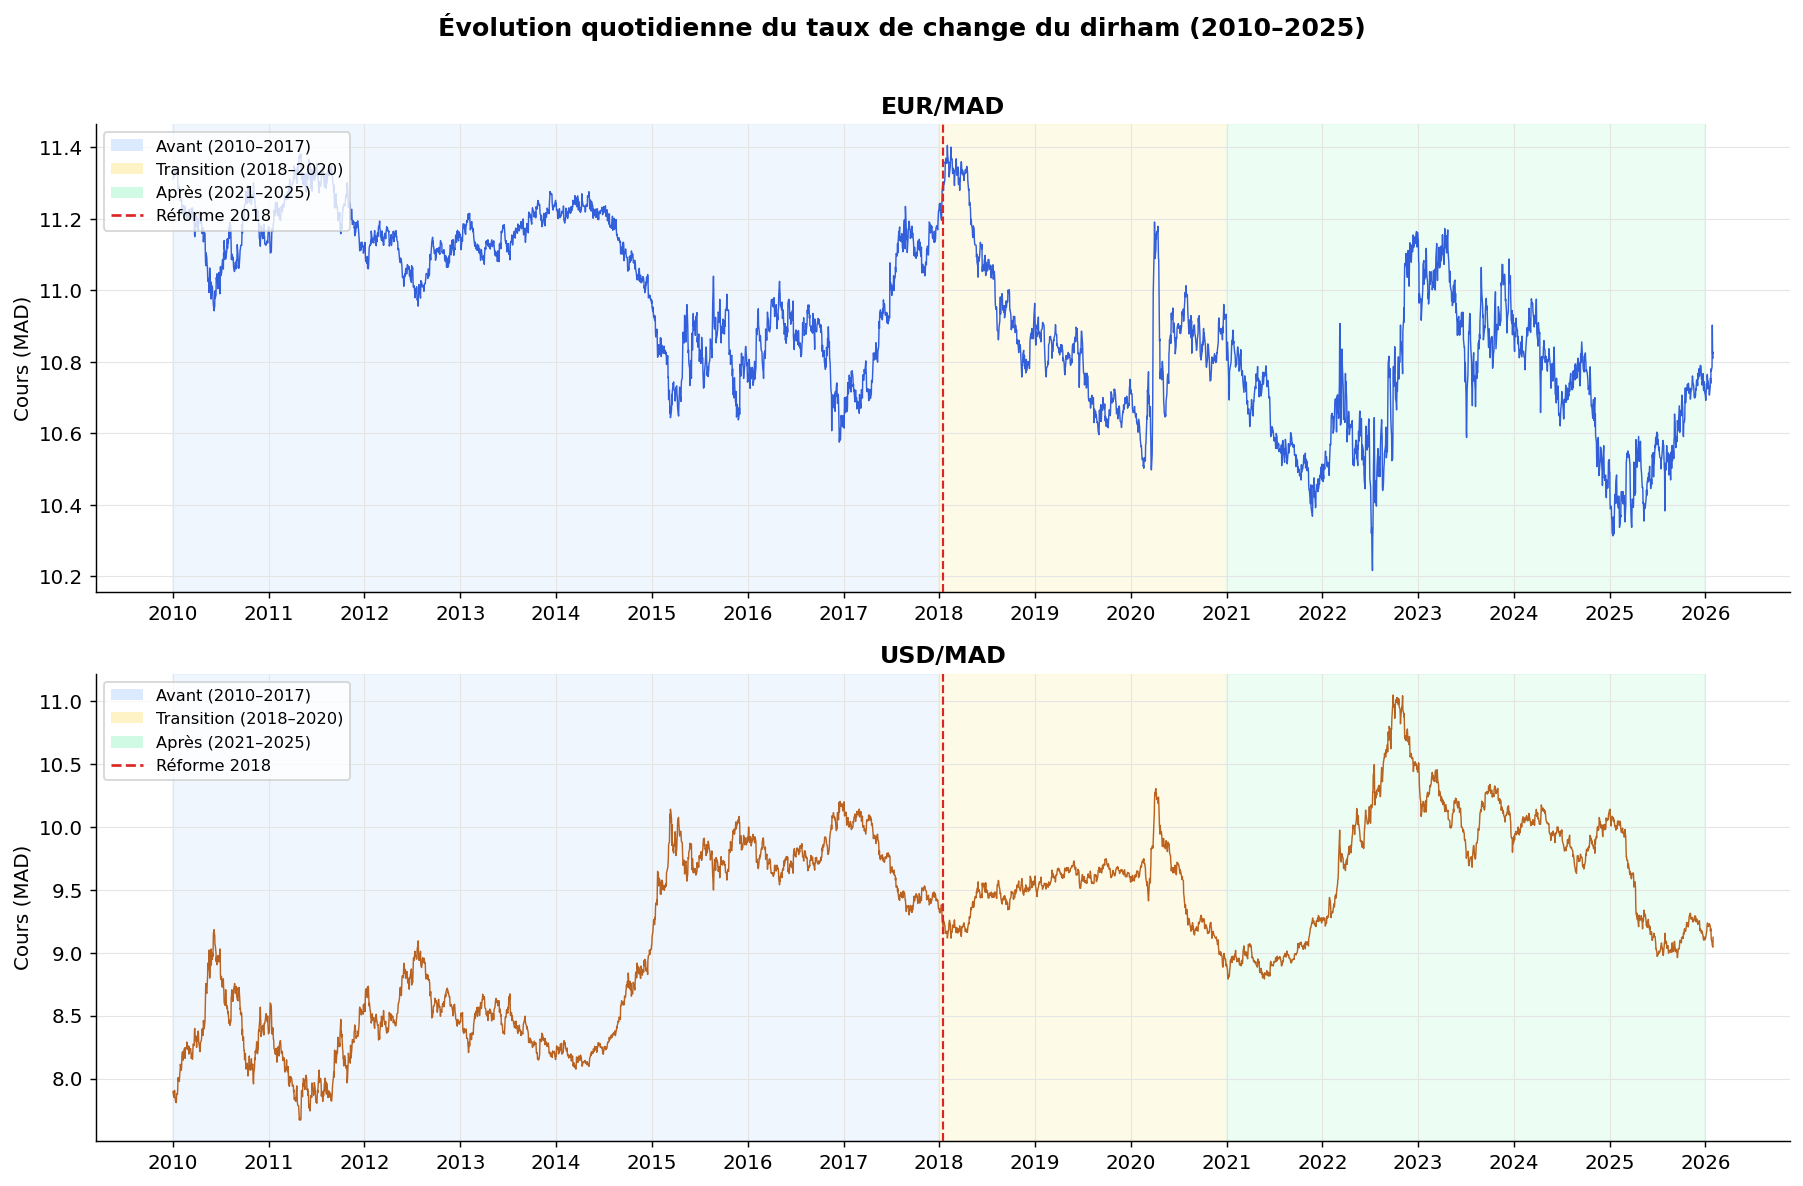

In [24]:
# Série chronologique EUR/MAD et USD/MAD

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=False)
fig.suptitle("Évolution quotidienne du taux de change du dirham (2010–2025)",
             fontsize=14, fontweight='bold', y=1.01)

for ax, (df, devise, color) in zip(axes, [
    (eur_mad, 'EUR/MAD', COLORS['eur']),
    (usd_mad, 'USD/MAD', COLORS['usd']),
]):
    ax.plot(df['Date'], df['Cours'], color=color,
            linewidth=0.8, alpha=0.9)
    add_bands(ax, is_date=True)
    ax.set_title(devise, fontweight='bold')
    ax.set_ylabel("Cours (MAD)")
    ax.legend(handles=legend_periodes(), loc='upper left',
              fontsize=9, framealpha=0.8)
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.savefig("../visualisation/viz_01_taux_change_serie.png", bbox_inches='tight', dpi=150)
plt.show()

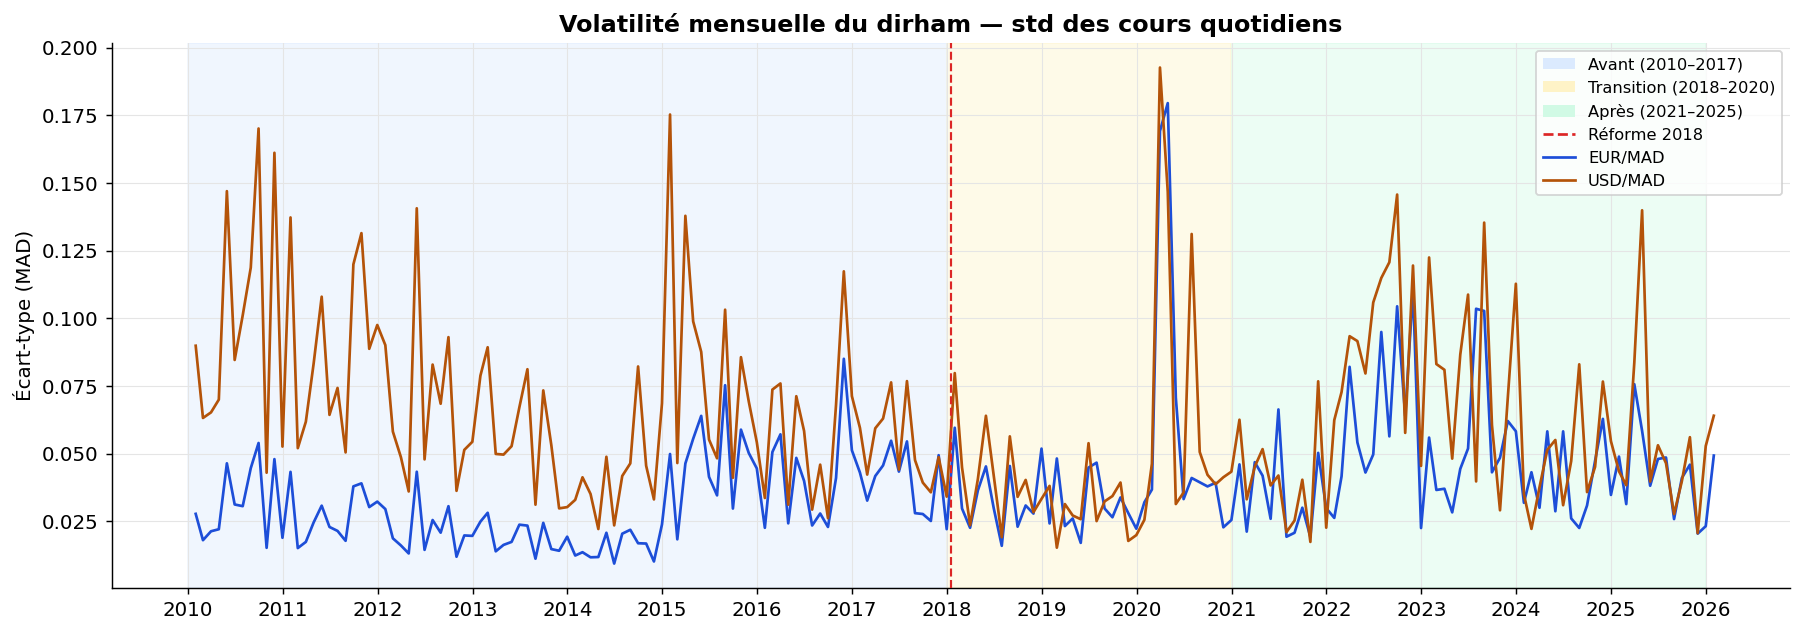

In [25]:
#  Volatilité mensuelle (std des cours quotidiens)
fig, ax = plt.subplots(figsize=(14, 5))

for df, devise, color in [
    (eur_mad, 'EUR/MAD', COLORS['eur']),
    (usd_mad, 'USD/MAD', COLORS['usd']),
]:
    vol = (df.set_index('Date')['Cours']
             .resample('M').std()
             .dropna())
    ax.plot(vol.index, vol.values,
            color=color, linewidth=1.5, label=devise)

add_bands(ax, is_date=True)
ax.set_title("Volatilité mensuelle du dirham — std des cours quotidiens",
             fontweight='bold')
ax.set_ylabel("Écart-type (MAD)")
ax.legend(handles=legend_periodes() + [
    plt.Line2D([0],[0], color=COLORS['eur'], label='EUR/MAD'),
    plt.Line2D([0],[0], color=COLORS['usd'], label='USD/MAD'),
], fontsize=9)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.savefig("../visualisation/viz_02_volatilite.png", bbox_inches='tight', dpi=150)
plt.show()

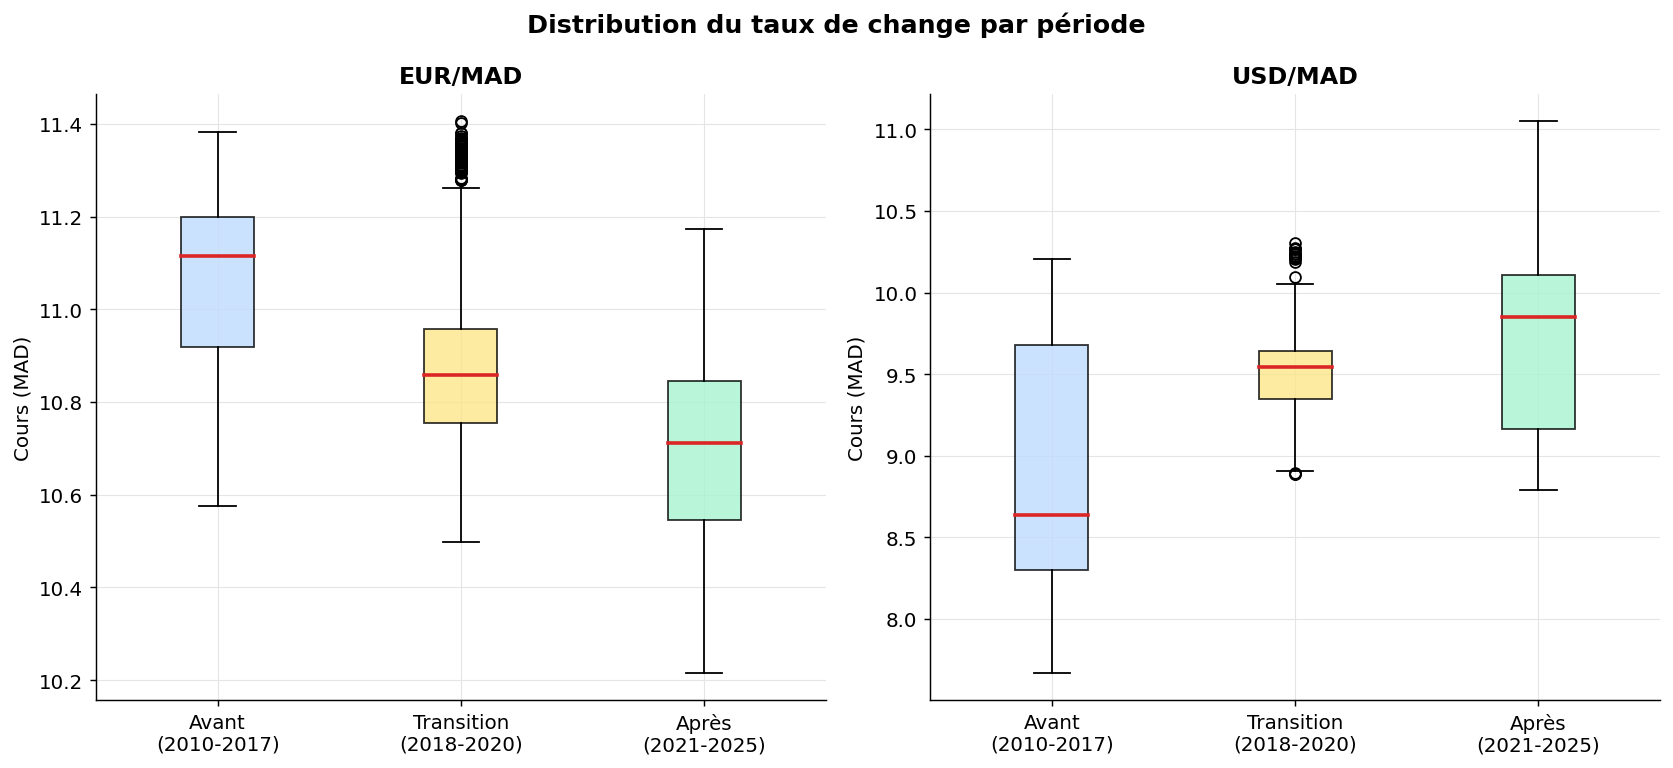

In [26]:
#  Boxplot de la distribution par période

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
fig.suptitle("Distribution du taux de change par période",
             fontsize=14, fontweight='bold')

for ax, (df, devise) in zip(axes, [
    (eur_mad, 'EUR/MAD'),
    (usd_mad, 'USD/MAD'),
]):
    data_per_period = []
    labels = []
    colors_box = ['#BFDBFE', '#FDE68A', '#A7F3D0']

    for label, (debut, fin) in PERIODES.items():
        mask = df['Date'].dt.year.between(debut, fin)
        data_per_period.append(df.loc[mask, 'Cours'].values)
        labels.append(label.replace(' (', '\n('))

    bp = ax.boxplot(data_per_period, labels=labels,
                    patch_artist=True, notch=False,
                    medianprops=dict(color='#DC2626', linewidth=2))

    for patch, color in zip(bp['boxes'], colors_box):
        patch.set_facecolor(color)
        patch.set_alpha(0.8)

    ax.set_title(devise, fontweight='bold')
    ax.set_ylabel("Cours (MAD)")
    ax.grid(axis='y', color='#E5E5E5', linewidth=0.6)

plt.tight_layout()
plt.savefig("../visualisation/viz_03_boxplot_periodes.png", bbox_inches='tight', dpi=150)
plt.show()

<style>
T1 {
    display: inline-block;
    background: #fef2eb;
    color: #fc8530e1;
    padding: 10px 16px;
    border-radius: 8px; 
    font-size: 20px;
    font-weight: 900;
    font-family: "Segoe UI", Roboto, Arial, sans-serif;
    box-shadow: 0 4px 10px rgba(0,0,0,0.12);
    letter-spacing: 0.2px;
    border: 1px solid rgba(255,255,255,0.15);
}
</style>

<T1>2. IPC</T1>

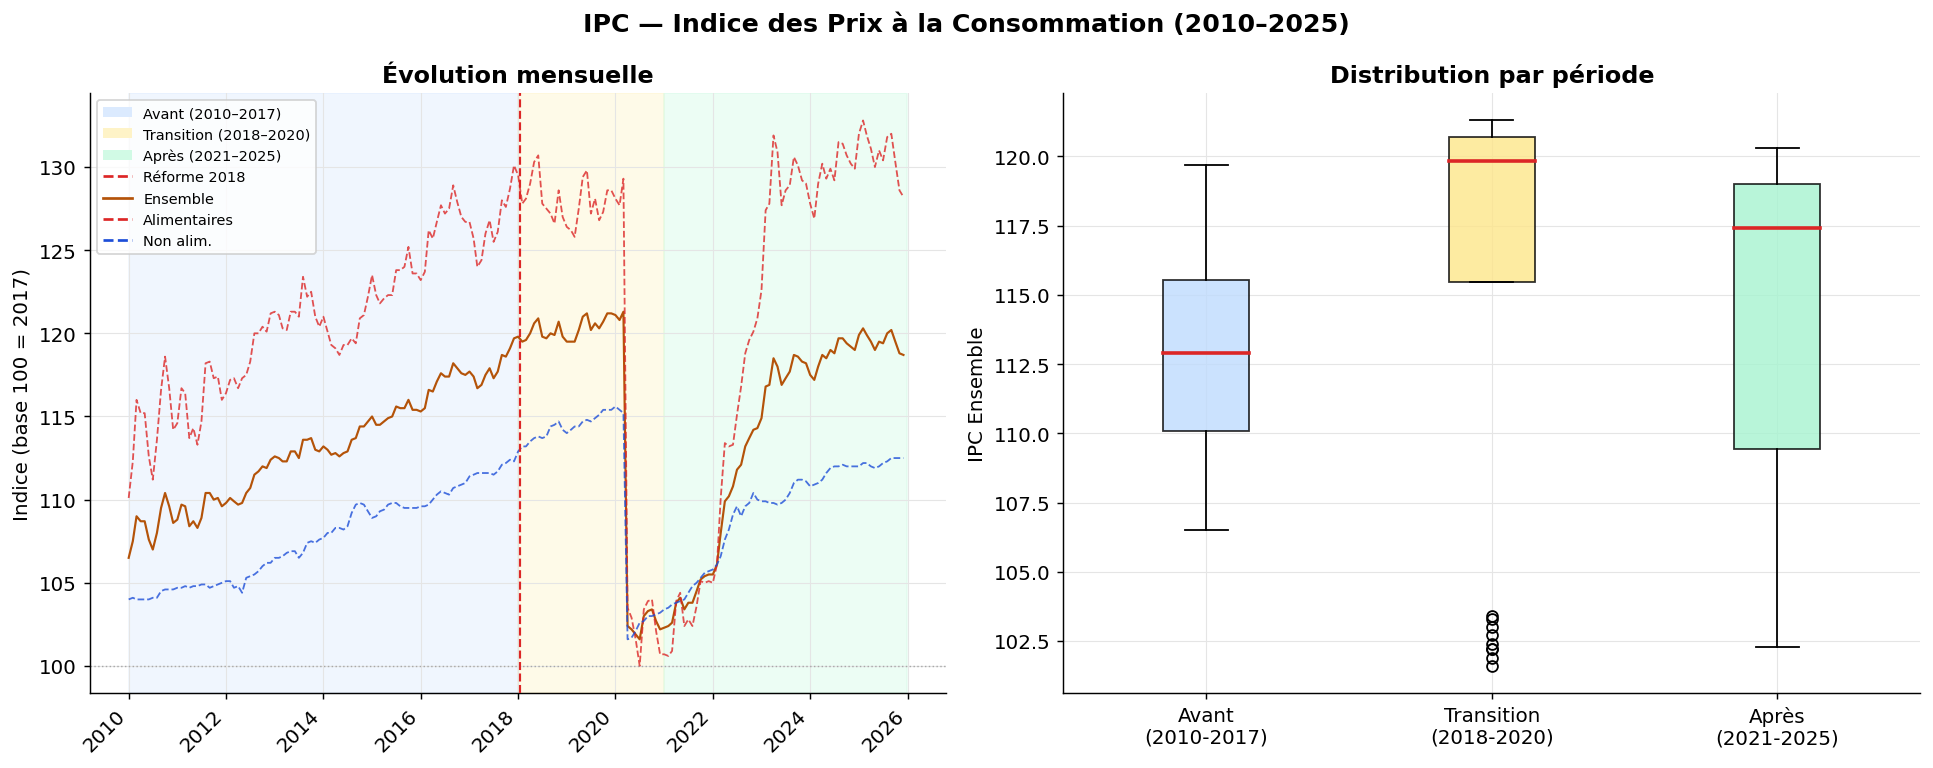

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("IPC — Indice des Prix à la Consommation (2010–2025)",
             fontsize=14, fontweight='bold')

ipc_clean = dfs_dict['ipc_cleaned'].copy()
ipc_clean['date'] = pd.to_datetime(ipc_clean['date'])

# Gauche : série mensuelle
ax = axes[0]
ax.plot(ipc_clean['date'], ipc_clean['Ensemble'],
        color='#B45309', linewidth=1.2, label='IPC Ensemble')
ax.plot(ipc_clean['date'], ipc_clean['Produits alimentaires'],
        color='#DC2626', linewidth=1, linestyle='--', alpha=0.8,
        label='Alimentaires')
ax.plot(ipc_clean['date'], ipc_clean['Produits non alimentaires'],
        color='#1D4ED8', linewidth=1, linestyle='--', alpha=0.8,
        label='Non alimentaires')
ax.axhline(100, color='gray', linewidth=0.8, linestyle=':', alpha=0.6)
add_bands(ax, is_date=True)
ax.set_title("Évolution mensuelle", fontweight='bold')
ax.set_ylabel("Indice (base 100 = 2017)")
ax.legend(handles=legend_periodes() + [
    plt.Line2D([0],[0], color='#B45309', label='Ensemble'),
    plt.Line2D([0],[0], color='#DC2626', linestyle='--', label='Alimentaires'),
    plt.Line2D([0],[0], color='#1D4ED8', linestyle='--', label='Non alim.'),
], fontsize=8)
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

# Droite : boxplot par période
ax = axes[1]
data_box = []
labels_box = []
colors_box = ['#BFDBFE', '#FDE68A', '#A7F3D0']
for label, (debut, fin) in PERIODES.items():
    mask = ipc_clean['annee'].between(debut, fin)
    data_box.append(ipc_clean.loc[mask, 'Ensemble'].values)
    labels_box.append(label.replace(' (', '\n('))

bp = ax.boxplot(data_box, labels=labels_box,
                patch_artist=True,
                medianprops=dict(color='#DC2626', linewidth=2))
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
ax.set_title("Distribution par période", fontweight='bold')
ax.set_ylabel("IPC Ensemble")
ax.grid(axis='y', color='#E5E5E5', linewidth=0.6)

plt.tight_layout()
plt.savefig("../visualisation/viz_04_ipc.png", bbox_inches='tight', dpi=150)
plt.show()

<style>
T1 {
    display: inline-block;
    background: #fef2eb;
    color: #fc8530e1;
    padding: 10px 16px;
    border-radius: 8px; 
    font-size: 20px;
    font-weight: 900;
    font-family: "Segoe UI", Roboto, Arial, sans-serif;
    box-shadow: 0 4px 10px rgba(0,0,0,0.12);
    letter-spacing: 0.2px;
    border: 1px solid rgba(255,255,255,0.15);
}
</style>

<T1>3. IDE</T1>

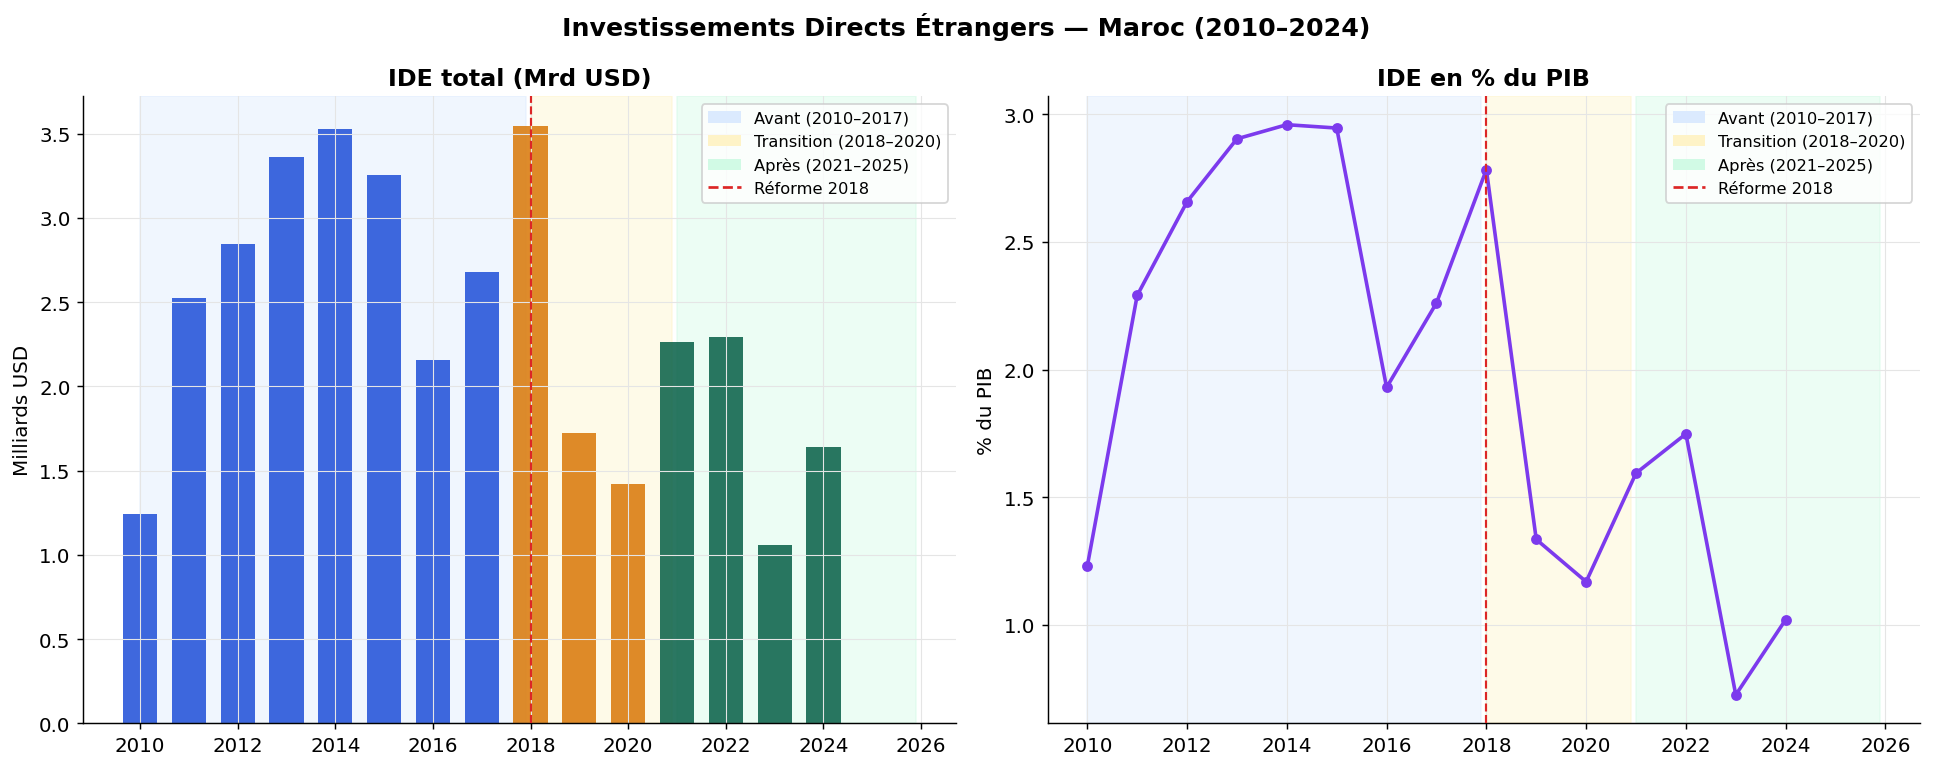

In [28]:
ide_g = dfs_dict['ide_global_cleaned'].copy()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("Investissements Directs Étrangers — Maroc (2010–2024)",
             fontsize=14, fontweight='bold')

# Gauche : IDE en barres
ax = axes[0]
bar_colors = [COLORS['avant'] if y <= 2017
              else COLORS['transition'] if y <= 2020
              else COLORS['apres']
              for y in ide_g['Year']]
ax.bar(ide_g['Year'], ide_g['IDE_USD'] / 1e9,
       color=bar_colors, alpha=0.85, width=0.7)
add_bands(ax, is_date=False)
ax.set_title("IDE total (Mrd USD)", fontweight='bold')
ax.set_ylabel("Milliards USD")
ax.legend(handles=legend_periodes(), fontsize=9)

# Droite : IDE % PIB
ax = axes[1]
ax.plot(ide_g['Year'], ide_g['IDE_percent_GDP'],
        color='#7C3AED', linewidth=2, marker='o', markersize=5)
add_bands(ax, is_date=False)
ax.set_title("IDE en % du PIB", fontweight='bold')
ax.set_ylabel("% du PIB")
ax.legend(handles=legend_periodes(), fontsize=9)

plt.tight_layout()
plt.savefig("../visualisation/viz_05_ide.png", bbox_inches='tight', dpi=150)
plt.show()

<style>
T1 {
    display: inline-block;
    background: #fef2eb;
    color: #fc8530e1;
    padding: 10px 16px;
    border-radius: 8px; 
    font-size: 20px;
    font-weight: 900;
    font-family: "Segoe UI", Roboto, Arial, sans-serif;
    box-shadow: 0 4px 10px rgba(0,0,0,0.12);
    letter-spacing: 0.2px;
    border: 1px solid rgba(255,255,255,0.15);
}
</style>

<T1>4. Réserves, Croissance PIB, Solde courant</T1>

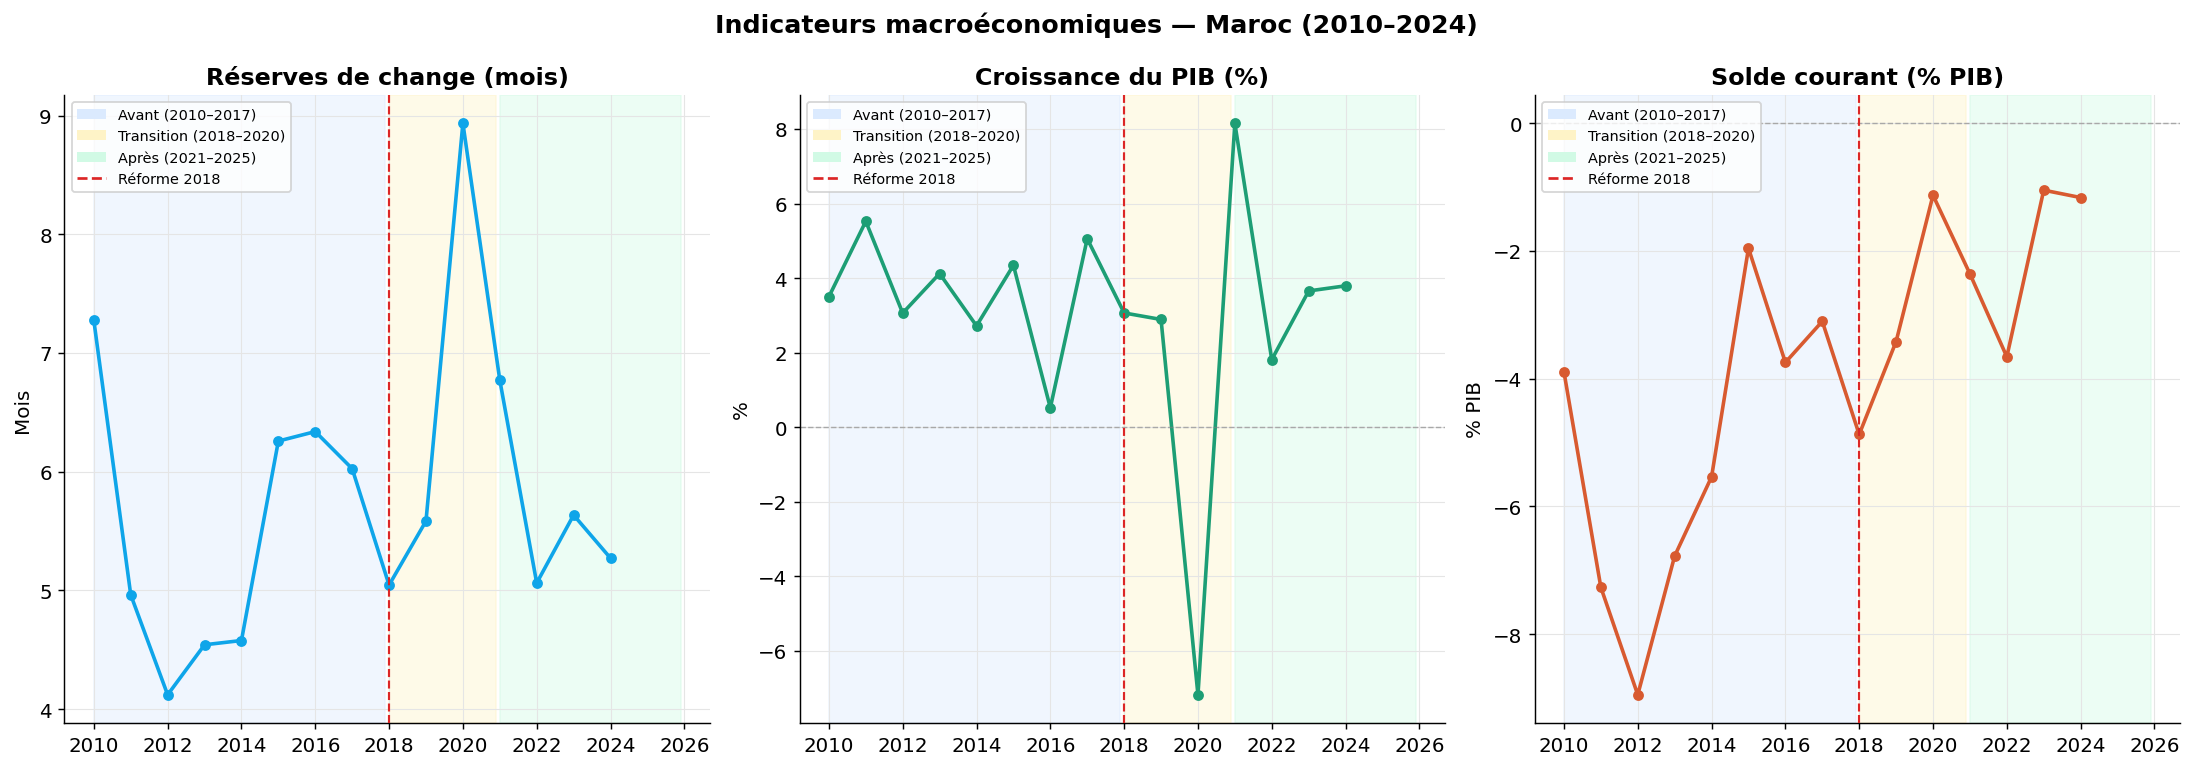

In [29]:
macro = dfs_dict['macro_cleaned'].copy()
res   = dfs_dict['reserves_cleaned'].copy()

fig, axes = plt.subplots(1, 3, figsize=(17, 6))
fig.suptitle("Indicateurs macroéconomiques — Maroc (2010–2024)",
             fontsize=14, fontweight='bold')

indicateurs = [
    (axes[0], res,   'year', 'value_months',   'Réserves de change (mois)', 'Mois', '#0EA5E9'),
    (axes[1], macro, 'year', 'gdp_growth',     'Croissance du PIB (%)',     '%',    '#1D9E75'),
    (axes[2], macro, 'year', 'current_account','Solde courant (% PIB)',     '% PIB','#D85A30'),
]

for ax, df, xcol, ycol, title, ylabel, color in indicateurs:
    ax.plot(df[xcol], df[ycol], color=color,
            linewidth=2, marker='o', markersize=5)
    add_bands(ax, is_date=False)
    if ycol in ['gdp_growth', 'current_account']:
        ax.axhline(0, color='gray', linewidth=0.8,
                   linestyle='--', alpha=0.6)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel(ylabel)
    ax.legend(handles=legend_periodes(), fontsize=8)

plt.tight_layout()
plt.savefig("../visualisation/viz_06_macro.png", bbox_inches='tight', dpi=150)
plt.show()

<style>
T1 {
    display: inline-block;
    background: #fef2eb;
    color: #fc8530e1;
    padding: 10px 16px;
    border-radius: 8px; 
    font-size: 20px;
    font-weight: 900;
    font-family: "Segoe UI", Roboto, Arial, sans-serif;
    box-shadow: 0 4px 10px rgba(0,0,0,0.12);
    letter-spacing: 0.2px;
    border: 1px solid rgba(255,255,255,0.15);
}
</style>

<T1>5. MASI</T1>

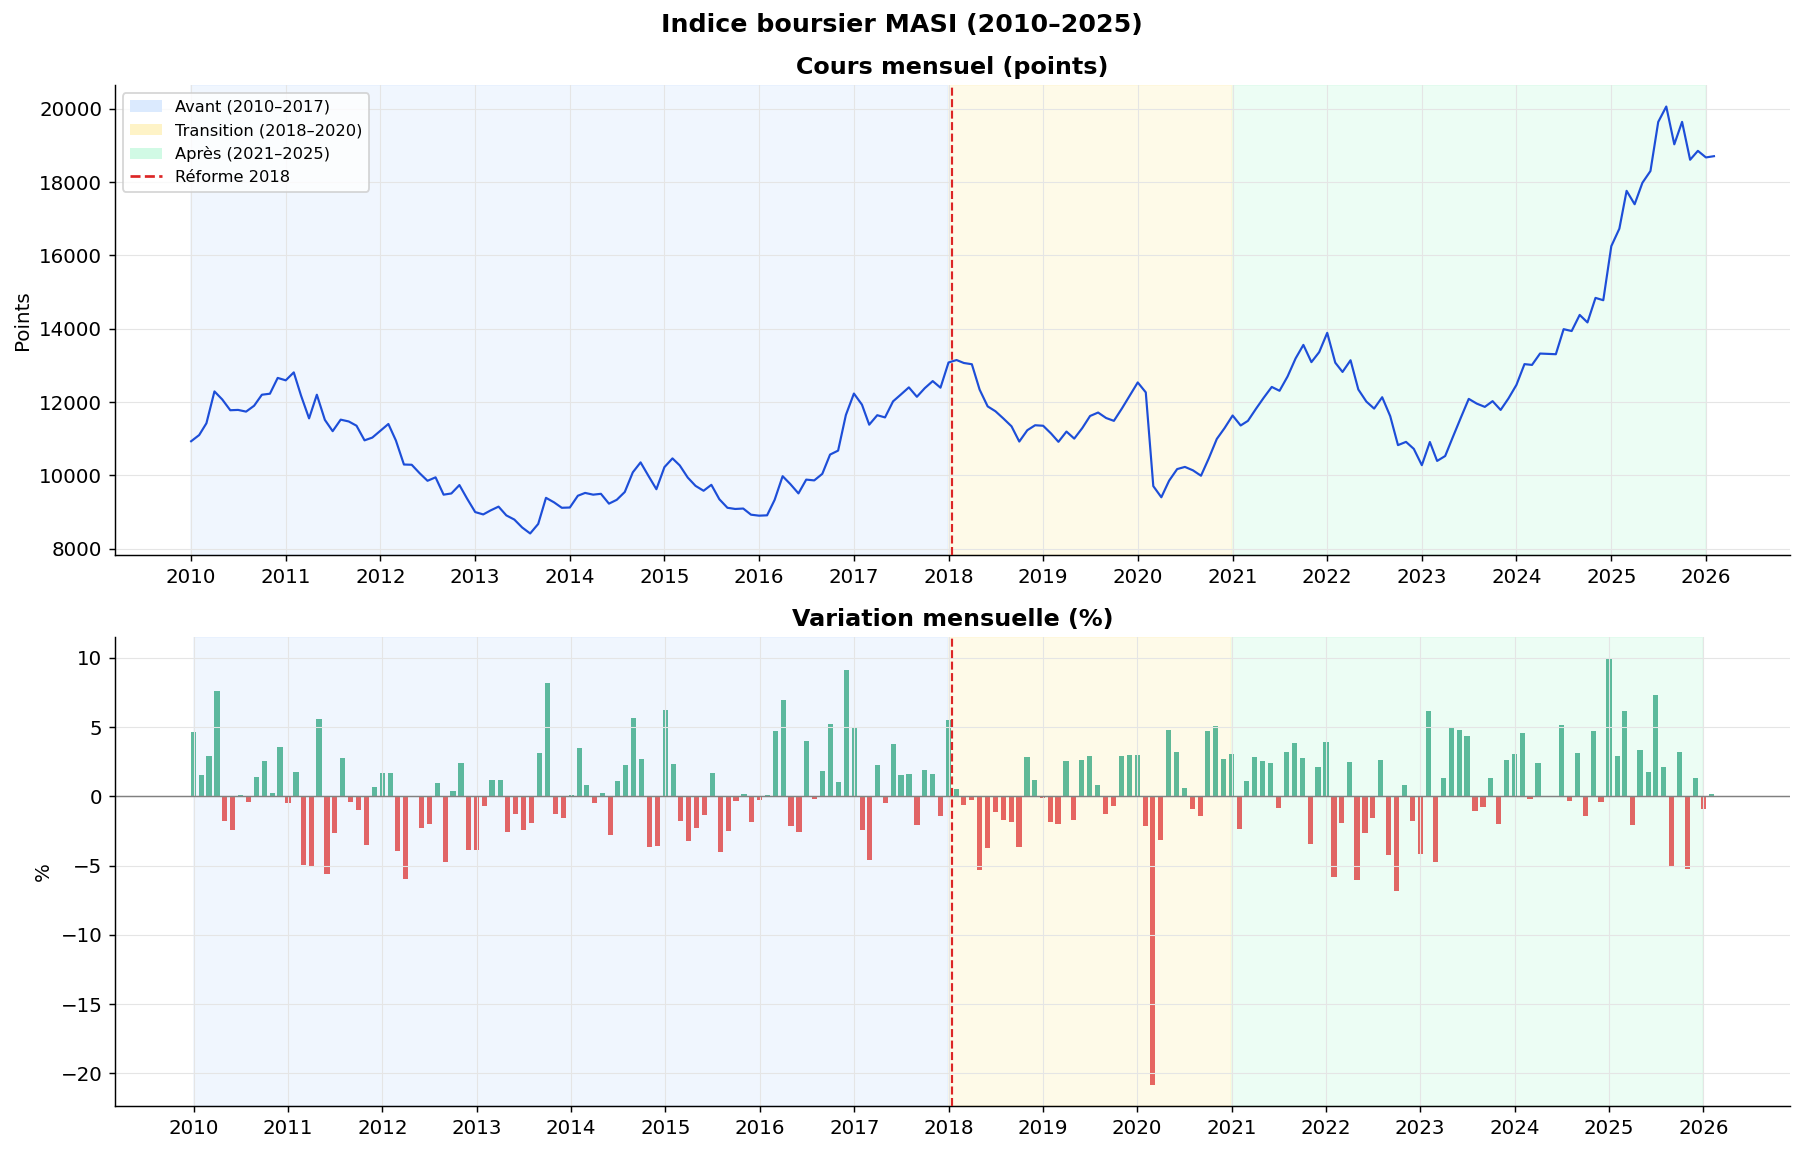

In [30]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=False)
fig.suptitle("Indice boursier MASI (2010–2025)",
             fontsize=14, fontweight='bold')

masi_clean = dfs_dict['masi_cleaned'].copy()
masi_clean['Date'] = pd.to_datetime(masi_clean['Date'])
masi_clean = masi_clean.sort_values('Date')

# Haut : cours mensuel
ax = axes[0]
ax.plot(masi_clean['Date'], masi_clean['Cloture'],
        color='#1D4ED8', linewidth=1.2)
add_bands(ax, is_date=True)
ax.set_title("Cours mensuel (points)", fontweight='bold')
ax.set_ylabel("Points")
ax.legend(handles=legend_periodes(), fontsize=9)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Bas : variation mensuelle
ax = axes[1]
colors_var = ['#1D9E75' if v >= 0 else '#DC2626'
              for v in masi_clean['Variation'].fillna(0)]
ax.bar(masi_clean['Date'], masi_clean['Variation'],
       color=colors_var, alpha=0.7, width=20)
ax.axhline(0, color='gray', linewidth=0.8)
add_bands(ax, is_date=True)
ax.set_title("Variation mensuelle (%)", fontweight='bold')
ax.set_ylabel("%")
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.savefig("../visualisation/viz_07_masi.png", bbox_inches='tight', dpi=150)
plt.show()

<style>
T1 {
    display: inline-block;
    background: linear-gradient(90deg,#ffb457,#ff7043);
    color: #fff;
    padding: 10px 16px;
    border-radius: 8px;
    font-size: 25px;
    font-weight: 900;
    font-family: "Segoe UI", Roboto, Arial, sans-serif;
    box-shadow: 0 4px 10px rgba(0,0,0,0.12);
    letter-spacing: 0.2px;
    border: 1px solid rgba(255,255,255,0.15);
}
</style>

<T1> Visualisation bivariée </T1>

<style>
T1 {
    display: inline-block;
    background: #fef2eb;
    color: #fc8530e1;
    padding: 10px 16px;
    border-radius: 8px; 
    font-size: 20px;
    font-weight: 900;
    font-family: "Segoe UI", Roboto, Arial, sans-serif;
    box-shadow: 0 4px 10px rgba(0,0,0,0.12);
    letter-spacing: 0.2px;
    border: 1px solid rgba(255,255,255,0.15);
}
</style>

<T1>1. Taux de change vs IPC</T1>

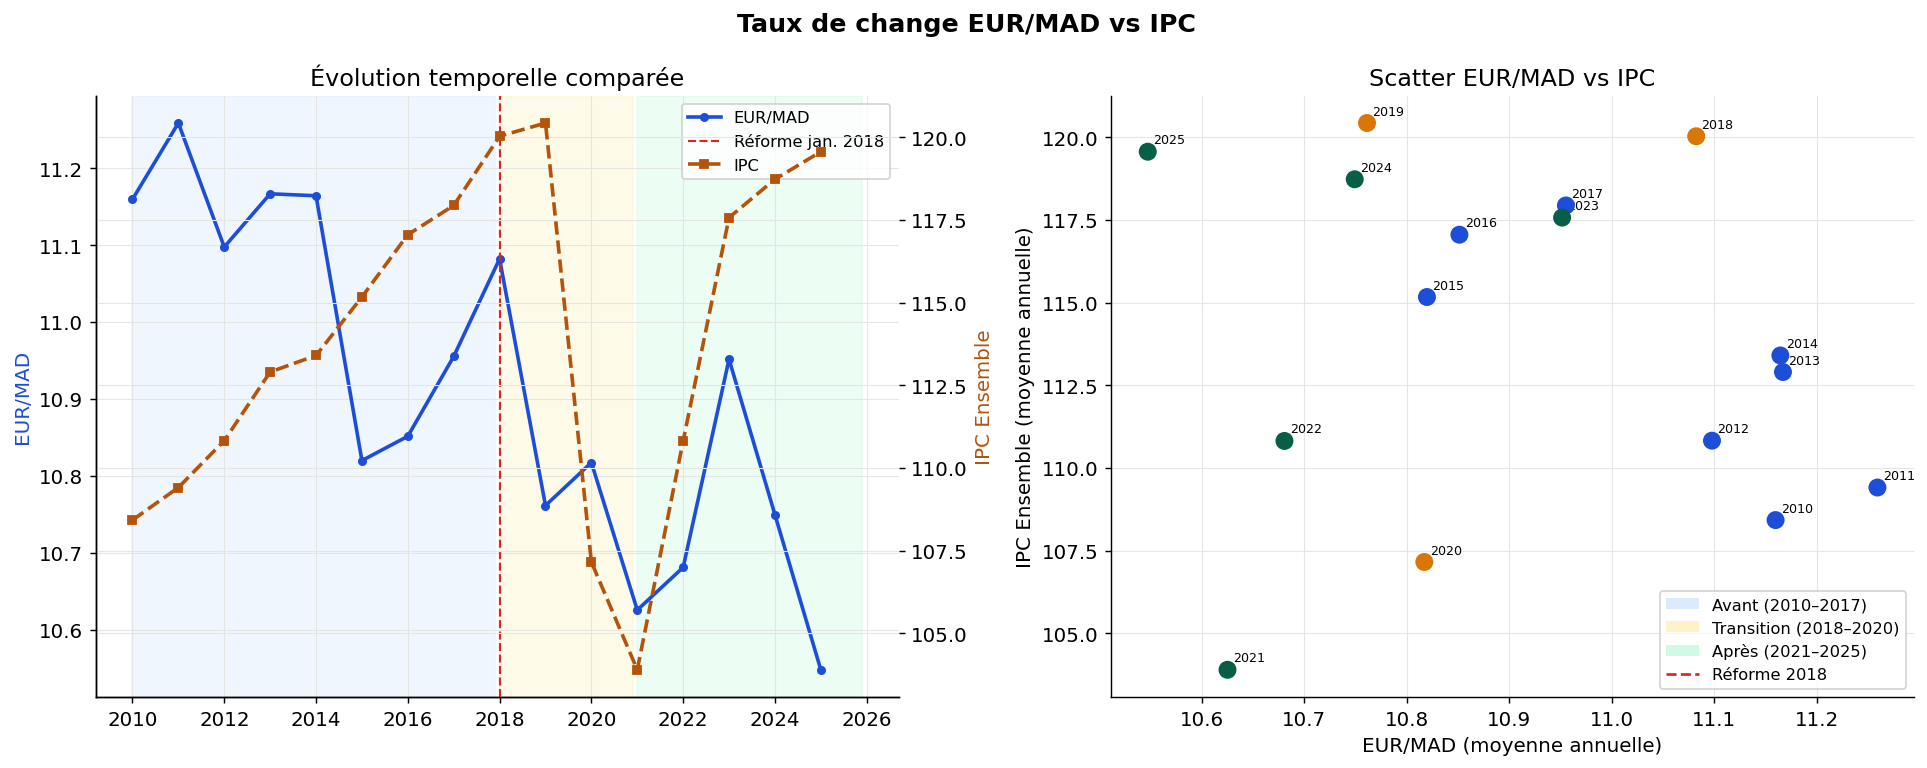

In [31]:
# Préparer les données annuelles
eur_ann = (eur_mad.set_index('Date')['Cours']
           .resample('Y').mean()
           .reset_index()
           .rename(columns={'Date':'year', 'Cours':'EUR_MAD'}))
eur_ann['year'] = eur_ann['year'].dt.year

ipc_ann = (ipc_clean.groupby('annee')['Ensemble']
           .mean().reset_index()
           .rename(columns={'annee':'year', 'Ensemble':'IPC'}))

df_tc_ipc = eur_ann.merge(ipc_ann, on='year')

# Couleur par période
def color_periode(y):
    if y <= 2017: return COLORS['avant']
    elif y <= 2020: return COLORS['transition']
    else: return COLORS['apres']

colors = df_tc_ipc['year'].apply(color_periode)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("Taux de change EUR/MAD vs IPC", fontsize=14, fontweight='bold')

# Gauche : double axe temporel
ax1 = axes[0]
ax2 = ax1.twinx()
ax1.plot(df_tc_ipc['year'], df_tc_ipc['EUR_MAD'],
         color=COLORS['eur'], linewidth=2, marker='o',
         markersize=4, label='EUR/MAD')
ax2.plot(df_tc_ipc['year'], df_tc_ipc['IPC'],
         color='#B45309', linewidth=2, marker='s',
         markersize=4, linestyle='--', label='IPC')
add_bands(ax1, is_date=False)
ax1.set_ylabel("EUR/MAD", color=COLORS['eur'])
ax2.set_ylabel("IPC Ensemble", color='#B45309')
ax1.set_title("Évolution temporelle comparée")
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=9)

# Droite : scatter
ax = axes[1]
scatter = ax.scatter(df_tc_ipc['EUR_MAD'], df_tc_ipc['IPC'],
                     c=colors, s=80, zorder=5)
for _, row in df_tc_ipc.iterrows():
    ax.annotate(str(int(row['year'])),
                (row['EUR_MAD'], row['IPC']),
                fontsize=7, ha='left', va='bottom',
                xytext=(3, 3), textcoords='offset points')
ax.set_xlabel("EUR/MAD (moyenne annuelle)")
ax.set_ylabel("IPC Ensemble (moyenne annuelle)")
ax.set_title("Scatter EUR/MAD vs IPC")
ax.legend(handles=legend_periodes(), fontsize=9)

plt.tight_layout()
plt.savefig("../visualisation/viz_08_tc_ipc.png", bbox_inches='tight', dpi=150)
plt.show()

<style>
T1 {
    display: inline-block;
    background: #fef2eb;
    color: #fc8530e1;
    padding: 10px 16px;
    border-radius: 8px; 
    font-size: 20px;
    font-weight: 900;
    font-family: "Segoe UI", Roboto, Arial, sans-serif;
    box-shadow: 0 4px 10px rgba(0,0,0,0.12);
    letter-spacing: 0.2px;
    border: 1px solid rgba(255,255,255,0.15);
}
</style>

<T1>2. Taux de change vs IDE</T1>

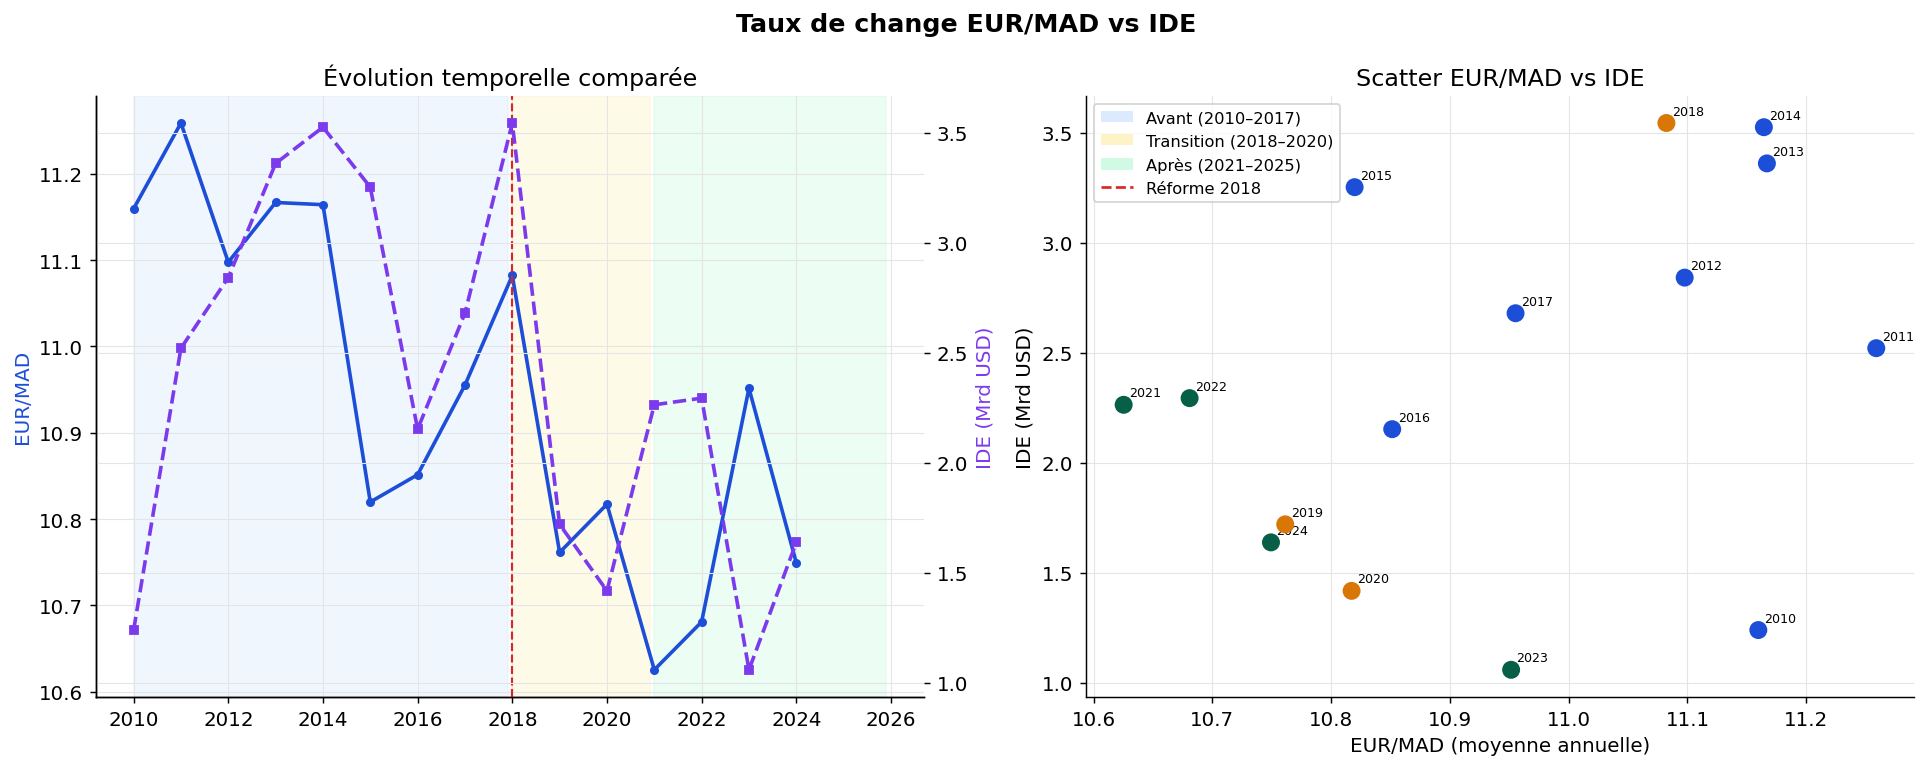

In [32]:
ide_g = dfs_dict['ide_global_cleaned'].copy()
df_tc_ide = eur_ann.merge(
    ide_g[['Year','IDE_USD','IDE_percent_GDP']].rename(columns={'Year':'year'}),
    on='year')
df_tc_ide['IDE_Mrd'] = df_tc_ide['IDE_USD'] / 1e9
colors = df_tc_ide['year'].apply(color_periode)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("Taux de change EUR/MAD vs IDE", fontsize=14, fontweight='bold')

# Gauche : double axe
ax1 = axes[0]
ax2 = ax1.twinx()
ax1.plot(df_tc_ide['year'], df_tc_ide['EUR_MAD'],
         color=COLORS['eur'], linewidth=2, marker='o', markersize=4)
ax2.plot(df_tc_ide['year'], df_tc_ide['IDE_Mrd'],
         color='#7C3AED', linewidth=2, marker='s',
         markersize=4, linestyle='--')
add_bands(ax1, is_date=False)
ax1.set_ylabel("EUR/MAD", color=COLORS['eur'])
ax2.set_ylabel("IDE (Mrd USD)", color='#7C3AED')
ax1.set_title("Évolution temporelle comparée")

# Droite : scatter
ax = axes[1]
ax.scatter(df_tc_ide['EUR_MAD'], df_tc_ide['IDE_Mrd'],
           c=colors, s=80, zorder=5)
for _, row in df_tc_ide.iterrows():
    ax.annotate(str(int(row['year'])),
                (row['EUR_MAD'], row['IDE_Mrd']),
                fontsize=7, ha='left', va='bottom',
                xytext=(3, 3), textcoords='offset points')
ax.set_xlabel("EUR/MAD (moyenne annuelle)")
ax.set_ylabel("IDE (Mrd USD)")
ax.set_title("Scatter EUR/MAD vs IDE")
ax.legend(handles=legend_periodes(), fontsize=9)

plt.tight_layout()
plt.savefig("../visualisation/viz_09_tc_ide.png", bbox_inches='tight', dpi=150)
plt.show()

<style>
T1 {
    display: inline-block;
    background: #fef2eb;
    color: #fc8530e1;
    padding: 10px 16px;
    border-radius: 8px; 
    font-size: 20px;
    font-weight: 900;
    font-family: "Segoe UI", Roboto, Arial, sans-serif;
    box-shadow: 0 4px 10px rgba(0,0,0,0.12);
    letter-spacing: 0.2px;
    border: 1px solid rgba(255,255,255,0.15);
}
</style>

<T1>3. Taux de change vs Solde courant et Réserves</T1>

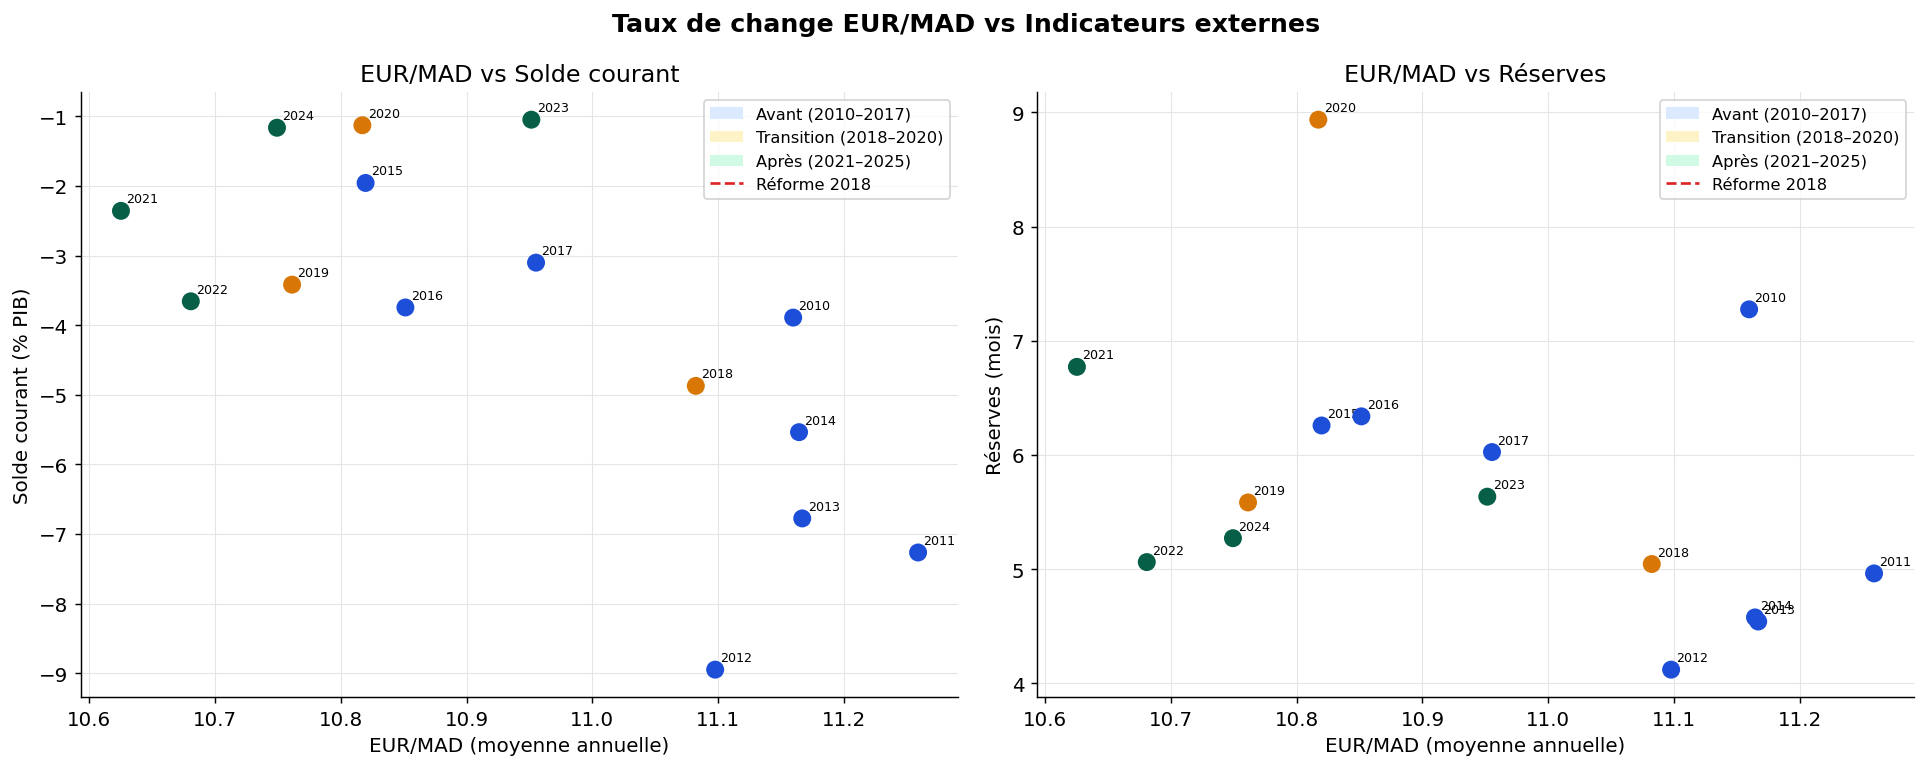

In [33]:
macro = dfs_dict['macro_cleaned'].copy()
res   = dfs_dict['reserves_cleaned'].copy()

df_tc_macro = (eur_ann
    .merge(macro[['year','current_account','gdp_growth']], on='year')
    .merge(res[['year','value_months']], on='year'))
colors = df_tc_macro['year'].apply(color_periode)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("Taux de change EUR/MAD vs Indicateurs externes",
             fontsize=14, fontweight='bold')

for ax, ycol, ylabel, color_line, title in [
    (axes[0], 'current_account', 'Solde courant (% PIB)', '#D85A30',
     'EUR/MAD vs Solde courant'),
    (axes[1], 'value_months',    'Réserves (mois)',        '#0EA5E9',
     'EUR/MAD vs Réserves'),
]:
    ax.scatter(df_tc_macro['EUR_MAD'], df_tc_macro[ycol],
               c=colors, s=80, zorder=5)
    for _, row in df_tc_macro.iterrows():
        ax.annotate(str(int(row['year'])),
                    (row['EUR_MAD'], row[ycol]),
                    fontsize=7, ha='left', va='bottom',
                    xytext=(3, 3), textcoords='offset points')
    ax.set_xlabel("EUR/MAD (moyenne annuelle)")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(handles=legend_periodes(), fontsize=9)

plt.tight_layout()
plt.savefig("../visualisation/viz_10_tc_macro.png", bbox_inches='tight', dpi=150)
plt.show()

<style>
T1 {
    display: inline-block;
    background: #fef2eb;
    color: #fc8530e1;
    padding: 10px 16px;
    border-radius: 8px; 
    font-size: 20px;
    font-weight: 900;
    font-family: "Segoe UI", Roboto, Arial, sans-serif;
    box-shadow: 0 4px 10px rgba(0,0,0,0.12);
    letter-spacing: 0.2px;
    border: 1px solid rgba(255,255,255,0.15);
}
</style>

<T1>4. Taux de change vs MASI</T1>

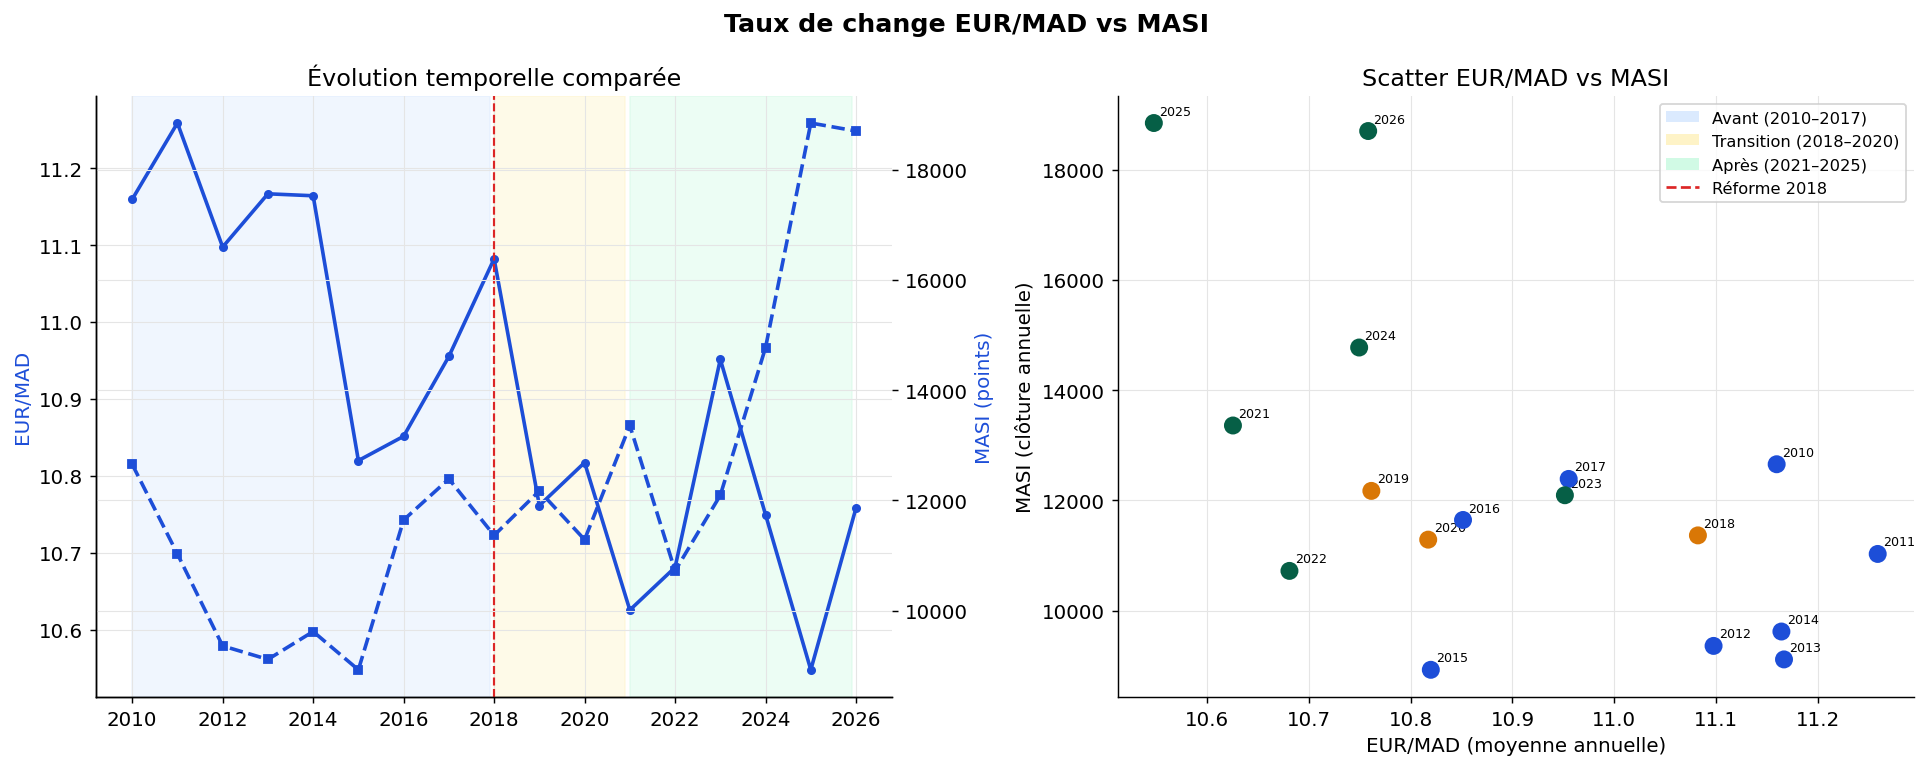

In [34]:
masi_ann = (dfs_dict['masi_cleaned'].copy()
            .assign(Date=lambda x: pd.to_datetime(x['Date']))
            .set_index('Date')['Cloture']
            .resample('Y').last()
            .reset_index()
            .rename(columns={'Date':'year', 'Cloture':'MASI'}))
masi_ann['year'] = masi_ann['year'].dt.year

df_tc_masi = eur_ann.merge(masi_ann, on='year')
colors = df_tc_masi['year'].apply(color_periode)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("Taux de change EUR/MAD vs MASI",
             fontsize=14, fontweight='bold')

# Gauche : double axe
ax1 = axes[0]
ax2 = ax1.twinx()
ax1.plot(df_tc_masi['year'], df_tc_masi['EUR_MAD'],
         color=COLORS['eur'], linewidth=2, marker='o', markersize=4)
ax2.plot(df_tc_masi['year'], df_tc_masi['MASI'],
         color='#1D4ED8', linewidth=2, marker='s',
         markersize=4, linestyle='--')
add_bands(ax1, is_date=False)
ax1.set_ylabel("EUR/MAD", color=COLORS['eur'])
ax2.set_ylabel("MASI (points)", color='#1D4ED8')
ax1.set_title("Évolution temporelle comparée")

# Droite : scatter
ax = axes[1]
ax.scatter(df_tc_masi['EUR_MAD'], df_tc_masi['MASI'],
           c=colors, s=80, zorder=5)
for _, row in df_tc_masi.iterrows():
    ax.annotate(str(int(row['year'])),
                (row['EUR_MAD'], row['MASI']),
                fontsize=7, ha='left', va='bottom',
                xytext=(3, 3), textcoords='offset points')
ax.set_xlabel("EUR/MAD (moyenne annuelle)")
ax.set_ylabel("MASI (clôture annuelle)")
ax.set_title("Scatter EUR/MAD vs MASI")
ax.legend(handles=legend_periodes(), fontsize=9)

plt.tight_layout()
plt.savefig("../visualisation/viz_11_tc_masi.png", bbox_inches='tight', dpi=150)
plt.show()

<style>
T1 {
    display: inline-block;
    background: linear-gradient(90deg,#ffb457,#ff7043);
    color: #fff;
    padding: 10px 16px;
    border-radius: 8px;
    font-size: 25px;
    font-weight: 900;
    font-family: "Segoe UI", Roboto, Arial, sans-serif;
    box-shadow: 0 4px 10px rgba(0,0,0,0.12);
    letter-spacing: 0.2px;
    border: 1px solid rgba(255,255,255,0.15);
}
</style>

<T1> Matrice de corrélations </T1>

In [35]:
#-----------------------------------------------------------Construire le tableau annuel consolidé

# Agréger toutes les séries à l'échelle annuelle
eur_ann = (eur_mad.set_index('Date')['Cours']
           .resample('Y').mean().reset_index()
           .rename(columns={'Date':'year', 'Cours':'EUR_MAD'}))
eur_ann['year'] = eur_ann['year'].dt.year

usd_ann = (usd_mad.set_index('Date')['Cours']
           .resample('Y').mean().reset_index()
           .rename(columns={'Date':'year', 'Cours':'USD_MAD'}))
usd_ann['year'] = usd_ann['year'].dt.year

# Volatilité annuelle EUR/MAD
vol_ann = (eur_mad.set_index('Date')['Cours']
           .resample('Y').std().reset_index()
           .rename(columns={'Date':'year', 'Cours':'Vol_EUR_MAD'}))
vol_ann['year'] = vol_ann['year'].dt.year

# MASI annuel
masi_ann = (dfs_dict['masi_cleaned'].copy()
            .assign(Date=lambda x: pd.to_datetime(x['Date']))
            .set_index('Date')['Cloture']
            .resample('Y').mean().reset_index()
            .rename(columns={'Date':'year', 'Cloture':'MASI'}))
masi_ann['year'] = masi_ann['year'].dt.year

# IPC annuel
ipc_ann = (ipc_clean.groupby('annee')[['Ensemble',
           'Produits alimentaires', 'Produits non alimentaires']]
           .mean().reset_index()
           .rename(columns={'annee':'year',
                            'Ensemble':'IPC',
                            'Produits alimentaires':'IPC_Alim',
                            'Produits non alimentaires':'IPC_NonAlim'}))

# Fusionner tout
df_master = (eur_ann
    .merge(usd_ann,   on='year')
    .merge(vol_ann,   on='year')
    .merge(masi_ann,  on='year')
    .merge(ipc_ann,   on='year')
    .merge(dfs_dict['ide_global_cleaned'][['Year','IDE_USD','IDE_percent_GDP']]
           .rename(columns={'Year':'year'}), on='year')
    .merge(dfs_dict['ice_global_cleaned'][['year','value_exports','value_imports']], on='year')
    .merge(dfs_dict['reserves_cleaned'][['year','value_months']], on='year')
    .merge(dfs_dict['macro_cleaned'][['year','gdp_growth','current_account']], on='year')
)

# Renommer pour lisibilité
df_master = df_master.rename(columns={
    'EUR_MAD':        'EUR/MAD',
    'USD_MAD':        'USD/MAD',
    'Vol_EUR_MAD':    'Vol. EUR/MAD',
    'IDE_USD':        'IDE (USD)',
    'IDE_percent_GDP':'IDE % PIB',
    'value_exports':  'Exports',
    'value_imports':  'Imports',
    'value_months':   'Réserves (mois)',
    'gdp_growth':     'Croiss. PIB',
    'current_account':'Solde courant',
})

print(f"Tableau master : {df_master.shape}")
print(f"Période : {df_master['year'].min()} → {df_master['year'].max()}")
display(df_master.head())

Tableau master : (15, 15)
Période : 2010 → 2024


,year,EUR/MAD,USD/MAD,Vol. EUR/MAD,MASI,IPC,IPC_Alim,IPC_NonAlim,IDE (USD),IDE % PIB,Exports,Imports,Réserves (mois),Croiss. PIB,Solde courant
0,2010,11.159631,8.425993,0.091115,11838.710833,108.425000,114.358333,104.216667,1.240626e+09,1.229982,3.004672e+10,4.009703e+10,7.274898,3.499557,-3.891495
1,2011,11.258932,8.093345,0.068554,11695.690000,109.408333,115.908333,104.808333,2.521362e+09,2.290468,3.517570e+10,4.939471e+10,4.962899,5.524645,-7.267035
2,2012,11.097631,8.634865,0.053727,10171.420000,110.825000,118.533333,105.366667,2.841954e+09,2.657587,3.432380e+10,4.932488e+10,4.120374,3.062344,-8.950347
3,2013,11.166846,8.408314,0.046239,8936.786667,112.900000,121.333333,106.950000,3.360910e+09,2.903863,3.501491e+10,5.046753e+10,4.541684,4.122213,-6.777319
4,2014,11.164299,8.414848,0.083053,9598.363333,113.400000,120.008333,108.716667,3.525385e+09,2.959254,3.589768e+10,4.974973e+10,4.577553,2.719244,-5.537833


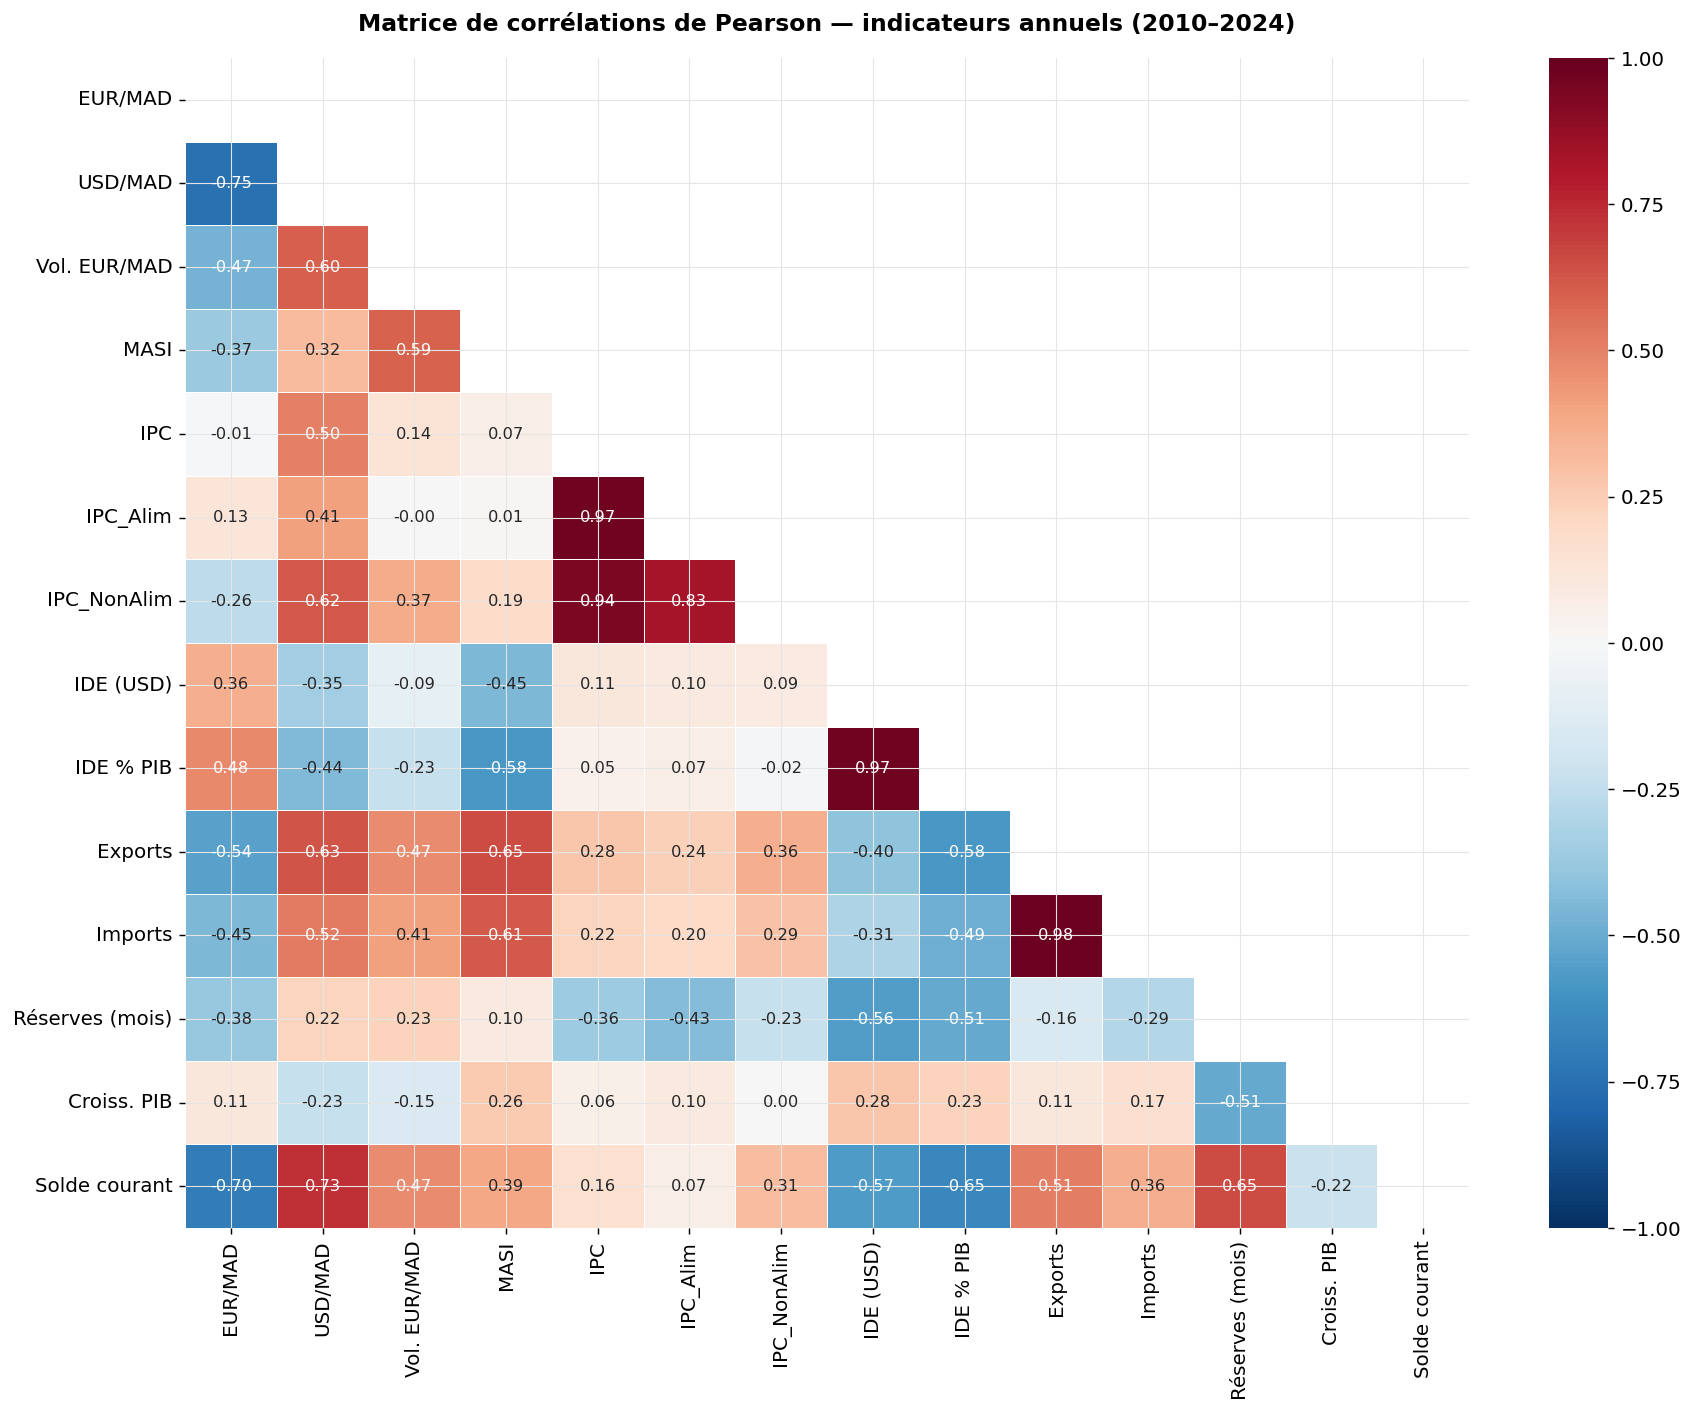

In [36]:
#-----------------------------------------------------------Matrice de corrélations

cols_corr = ['EUR/MAD', 'USD/MAD', 'Vol. EUR/MAD', 'MASI',
             'IPC', 'IPC_Alim', 'IPC_NonAlim',
             'IDE (USD)', 'IDE % PIB',
             'Exports', 'Imports', 'Réserves (mois)',
             'Croiss. PIB', 'Solde courant']

corr = df_master[cols_corr].corr(method='pearson').round(2)

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            ax=ax, linewidths=0.4,
            annot_kws={'size': 9})

ax.set_title("Matrice de corrélations de Pearson — indicateurs annuels (2010–2024)",
             fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig("../visualisation/viz_12_correlations.png", bbox_inches='tight', dpi=150)
plt.show()

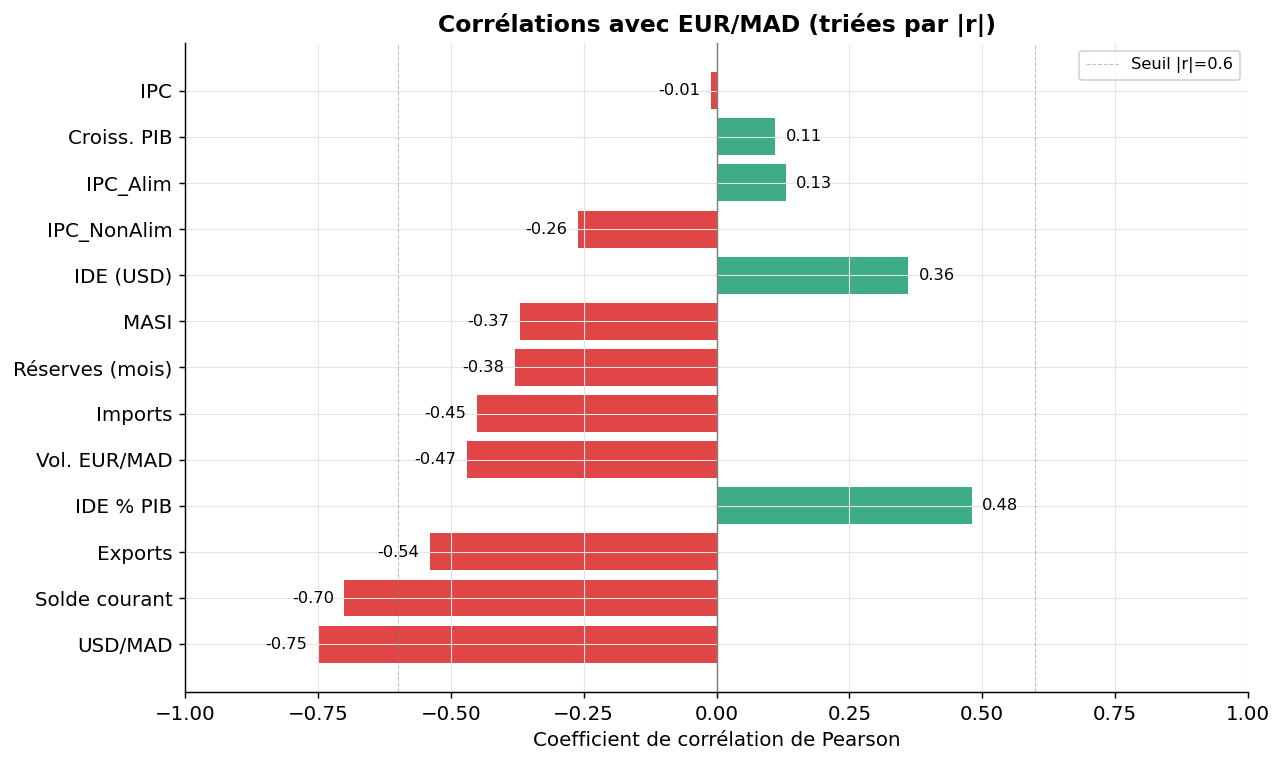


Corrélations fortes (|r| > 0.6) avec EUR/MAD :
USD/MAD         -0.75
Solde courant   -0.70


In [37]:
# Focus corrélations avec EUR/MAD

corr_tc = (corr['EUR/MAD']
           .drop('EUR/MAD')
           .sort_values(key=abs, ascending=False))

fig, ax = plt.subplots(figsize=(10, 6))
colors_bar = ['#1D9E75' if v > 0 else '#DC2626' for v in corr_tc.values]
bars = ax.barh(corr_tc.index, corr_tc.values,
               color=colors_bar, alpha=0.85)
ax.axvline(0,   color='gray', linewidth=0.8)
ax.axvline(0.6, color='gray', linewidth=0.6,
           linestyle='--', alpha=0.5, label='Seuil |r|=0.6')
ax.axvline(-0.6,color='gray', linewidth=0.6,
           linestyle='--', alpha=0.5)
ax.set_title("Corrélations avec EUR/MAD (triées par |r|)",
             fontsize=13, fontweight='bold')
ax.set_xlabel("Coefficient de corrélation de Pearson")
ax.set_xlim(-1, 1)
ax.legend(fontsize=9)

for bar, val in zip(bars, corr_tc.values):
    ax.text(val + (0.02 if val >= 0 else -0.02),
            bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center',
            ha='left' if val >= 0 else 'right',
            fontsize=9)

plt.tight_layout()
plt.savefig("../visualisation/viz_13_corr_tc.png", bbox_inches='tight', dpi=150)
plt.show()

print("\nCorrélations fortes (|r| > 0.6) avec EUR/MAD :")
print(corr_tc[abs(corr_tc) > 0.6].to_string())

<style>
T1 {
    display: inline-block;
    background: linear-gradient(90deg,#ffb457,#ff7043);
    color: #fff;
    padding: 10px 16px;
    border-radius: 8px;
    font-size: 25px;
    font-weight: 900;
    font-family: "Segoe UI", Roboto, Arial, sans-serif;
    box-shadow: 0 4px 10px rgba(0,0,0,0.12);
    letter-spacing: 0.2px;
    border: 1px solid rgba(255,255,255,0.15);
}
</style>

<T1> Analyse des Incohérences </T1>


EUR/MAD — 180 outliers détectés
           Date    Cours  Variation
1509 2020-04-20  10.8581      -2.06
1015 2022-03-11  10.6232      -1.57
872  2022-09-28  10.7535       1.56
469  2024-04-15  10.8132       1.46
1525 2020-03-27  10.9924       1.46
1526 2020-03-26  10.8341       1.44
2243 2017-06-27  11.0771       1.40
901  2022-08-18  10.4488      -1.33
2651 2015-12-03  10.7932       1.31
924  2022-07-18  10.6440       1.30

USD/MAD — 175 outliers détectés
           Date    Cours  Variation
4037 2010-08-11   8.6441       2.18
2837 2015-03-18   9.8548      -2.07
4066 2010-07-01   8.8256      -1.99
1509 2020-04-20  10.0029      -1.97
1524 2020-03-30  10.0522       1.85
3719 2011-10-31   8.1246       1.76
3712 2011-11-09   8.2641       1.74
923  2022-07-19  10.3159      -1.72
4097 2010-05-19   8.8663      -1.72
2876 2015-01-22   9.5402       1.71


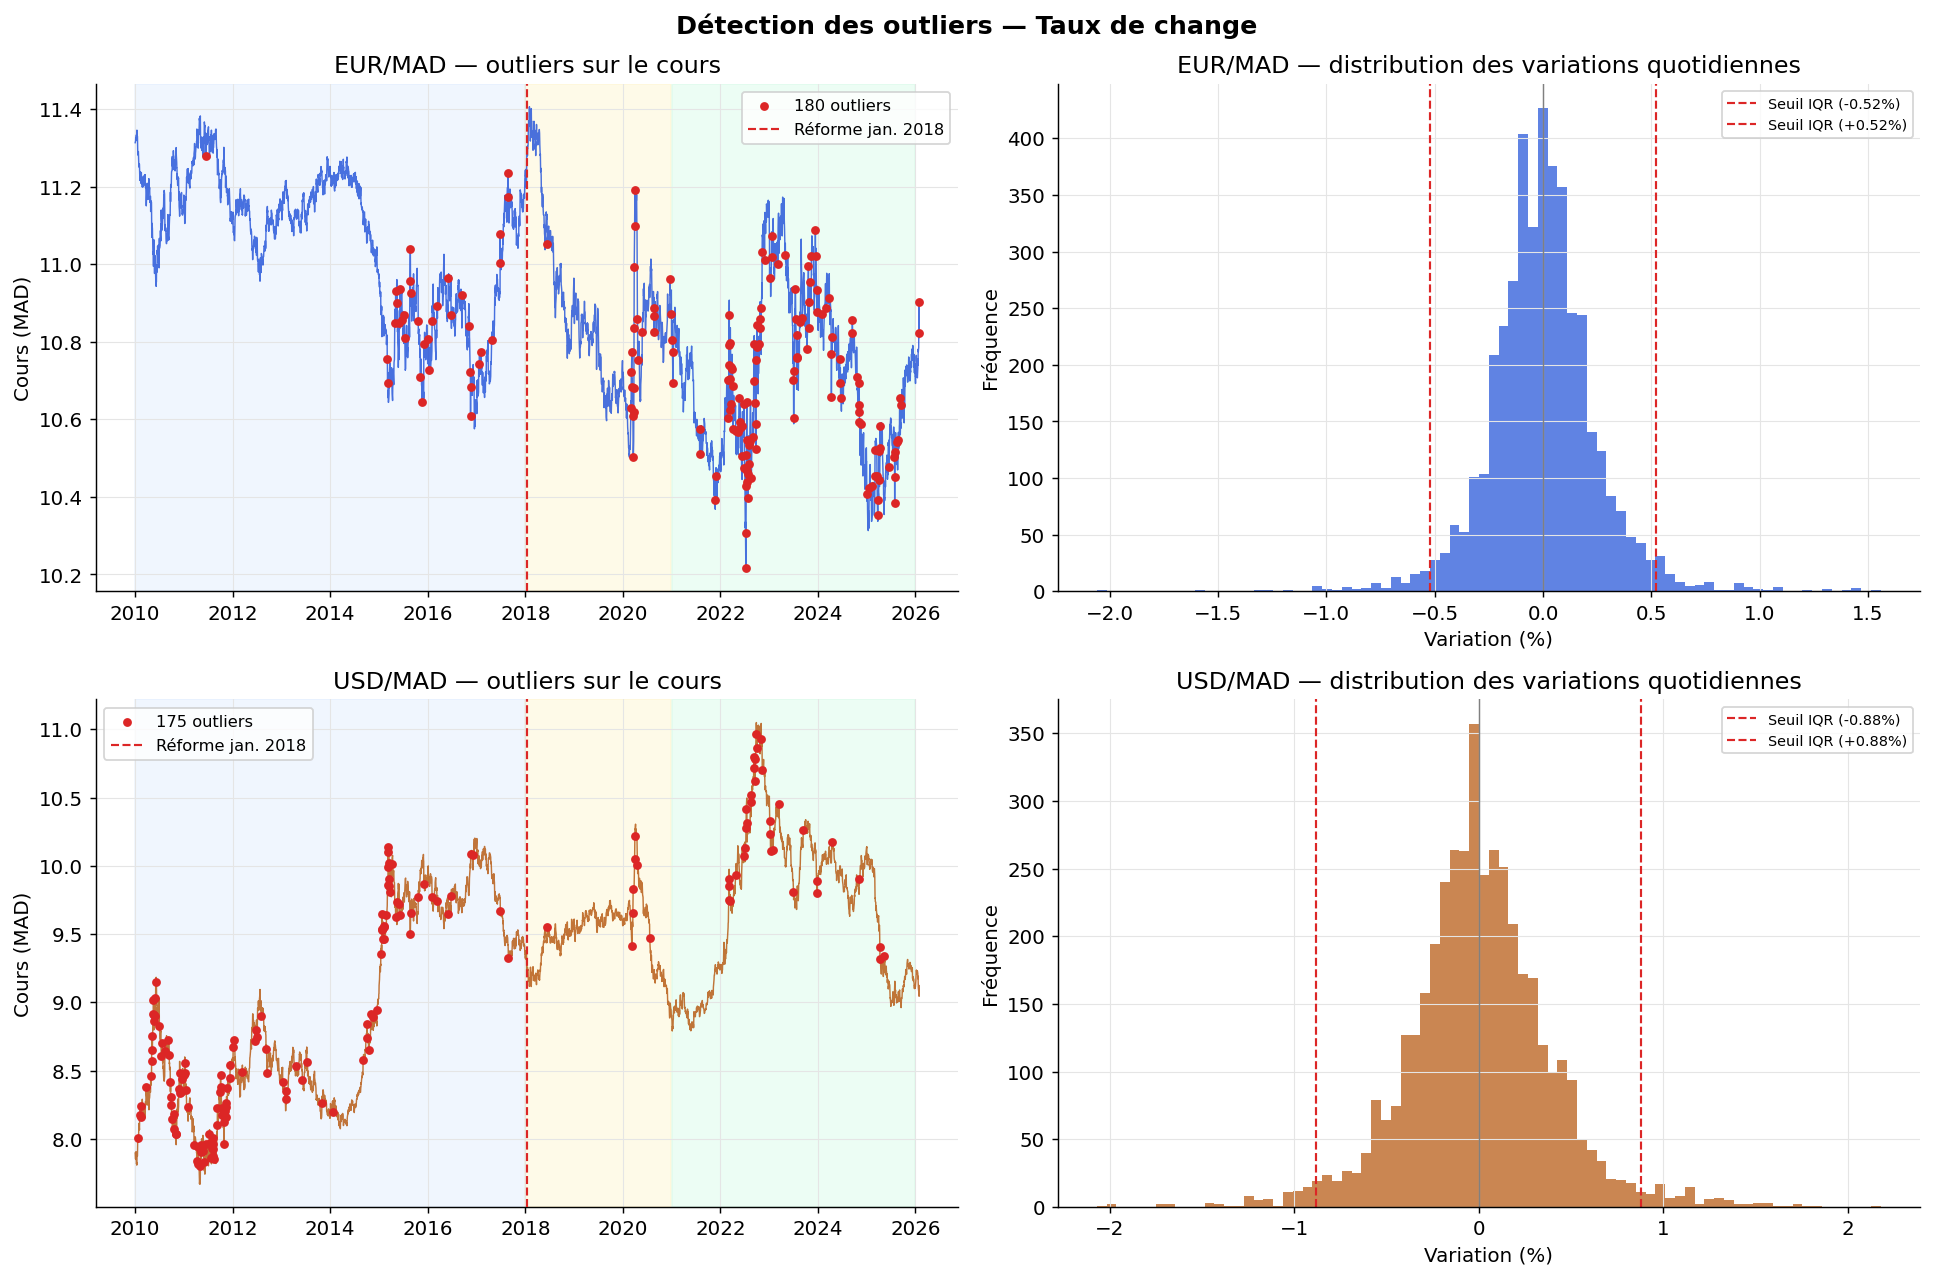

In [38]:
# Détection des outliers sur le taux de change

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle("Détection des outliers — Taux de change",
             fontsize=14, fontweight='bold')

for axes_row, (df, devise) in zip(axes, [
    (eur_mad, 'EUR/MAD'),
    (usd_mad, 'USD/MAD')
]):
    # Calculer les variations quotidiennes
    df = df.copy()
    df['Var_abs'] = df['Cours'].diff().abs()
    
    # Seuil IQR
    Q1 = df['Variation'].quantile(0.25)
    Q3 = df['Variation'].quantile(0.75)
    IQR = Q3 - Q1
    seuil_bas = Q1 - 1.5 * IQR
    seuil_haut = Q3 + 1.5 * IQR
    outliers = df[(df['Variation'] < seuil_bas) | 
                  (df['Variation'] > seuil_haut)]
    
    # Gauche : série avec outliers surlignés
    ax = axes_row[0]
    ax.plot(df['Date'], df['Cours'],
            color=COLORS['eur'] if devise=='EUR/MAD' else COLORS['usd'],
            linewidth=0.8, alpha=0.8)
    ax.scatter(outliers['Date'], outliers['Cours'],
               color='#DC2626', s=15, zorder=5, label=f'{len(outliers)} outliers')
    add_bands(ax, is_date=True)
    ax.set_title(f"{devise} — outliers sur le cours")
    ax.set_ylabel("Cours (MAD)")
    ax.legend(fontsize=9)
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    
    # Droite : distribution des variations
    ax = axes_row[1]
    ax.hist(df['Variation'].dropna(), bins=80,
            color=COLORS['eur'] if devise=='EUR/MAD' else COLORS['usd'],
            alpha=0.7, edgecolor='none')
    ax.axvline(seuil_bas,  color='#DC2626', linewidth=1.2,
               linestyle='--', label=f'Seuil IQR ({seuil_bas:.2f}%)')
    ax.axvline(seuil_haut, color='#DC2626', linewidth=1.2,
               linestyle='--', label=f'Seuil IQR (+{seuil_haut:.2f}%)')
    ax.axvline(0, color='gray', linewidth=0.8)
    ax.set_title(f"{devise} — distribution des variations quotidiennes")
    ax.set_xlabel("Variation (%)")
    ax.set_ylabel("Fréquence")
    ax.legend(fontsize=8)
    
    print(f"\n{devise} — {len(outliers)} outliers détectés")
    print(outliers[['Date','Cours','Variation']]
          .sort_values('Variation', key=abs, ascending=False)
          .head(10).to_string())

plt.tight_layout()
plt.savefig("../visualisation/viz_14_outliers_tc.png", bbox_inches='tight', dpi=150)
plt.show()

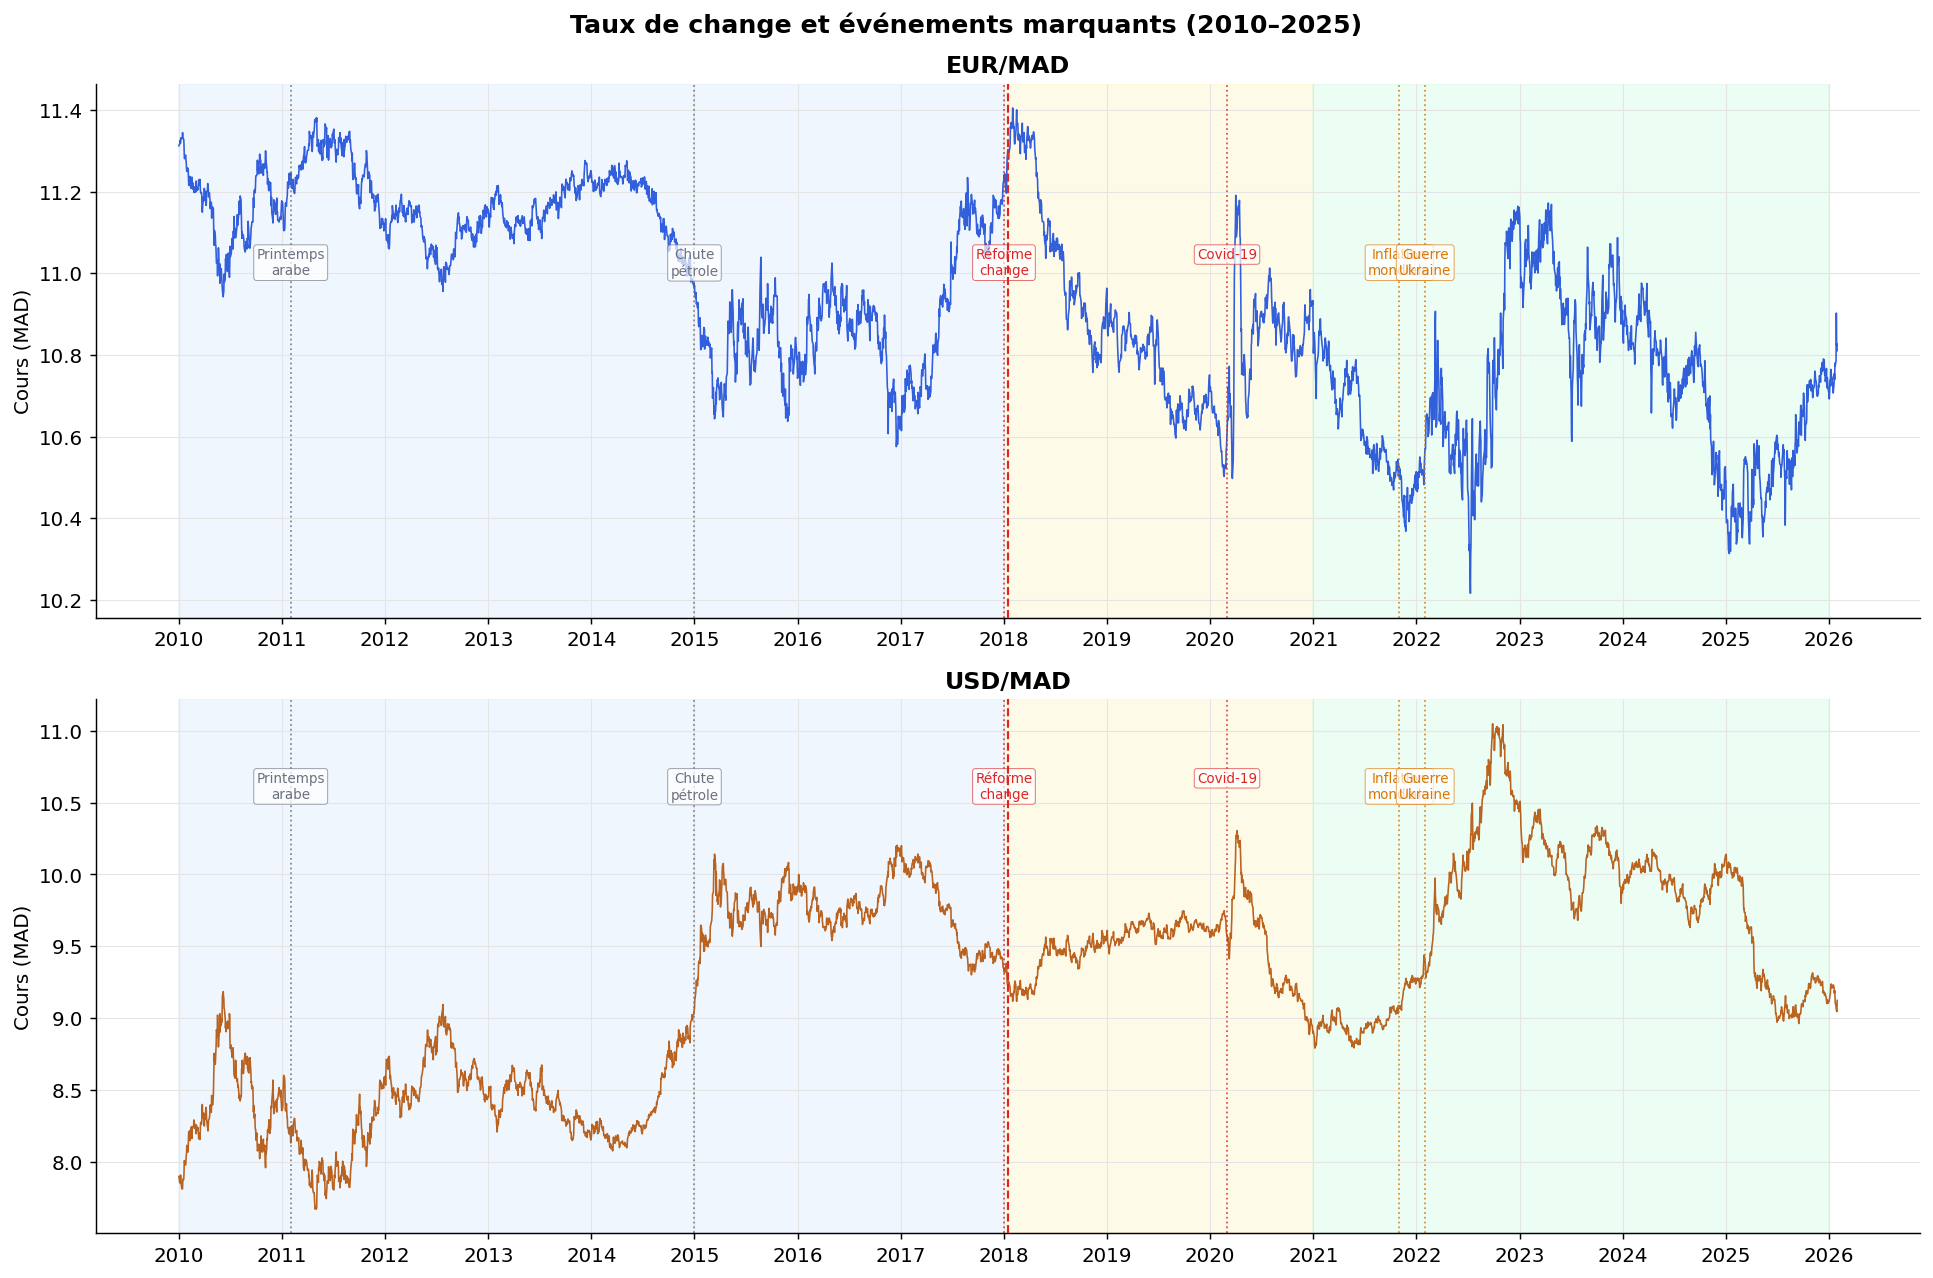

In [39]:
# Événements marquants annotés

EVENEMENTS = [
    ('2011-02', 'Printemps\narabe',     '#6B7280'),
    ('2015-01', 'Chute\npétrole',       '#6B7280'),
    ('2018-01', 'Réforme\nchange',      '#DC2626'),
    ('2020-03', 'Covid-19',             '#DC2626'),
    ('2021-11', 'Inflation\nmondiale',  '#D97706'),
    ('2022-02', 'Guerre\nUkraine',      '#D97706'),
]

fig, axes = plt.subplots(2, 1, figsize=(15, 10), sharex=False)
fig.suptitle("Taux de change et événements marquants (2010–2025)",
             fontsize=14, fontweight='bold')

for ax, (df, devise, color) in zip(axes, [
    (eur_mad, 'EUR/MAD', COLORS['eur']),
    (usd_mad, 'USD/MAD', COLORS['usd']),
]):
    ax.plot(df['Date'], df['Cours'],
            color=color, linewidth=0.9, alpha=0.9)
    add_bands(ax, is_date=True)
    
    for date_str, label, col in EVENEMENTS:
        date = pd.Timestamp(date_str)
        ax.axvline(date, color=col, linewidth=1,
                   linestyle=':', alpha=0.8)
        y_pos = df['Cours'].max() * 0.97
        ax.annotate(label,
                    xy=(date, y_pos),
                    fontsize=7.5, color=col,
                    ha='center', va='top',
                    bbox=dict(boxstyle='round,pad=0.2',
                              facecolor='white', alpha=0.7,
                              edgecolor=col, linewidth=0.5))
    
    ax.set_title(devise, fontweight='bold')
    ax.set_ylabel("Cours (MAD)")
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.savefig("../visualisation/viz_15_evenements.png", bbox_inches='tight', dpi=150)
plt.show()

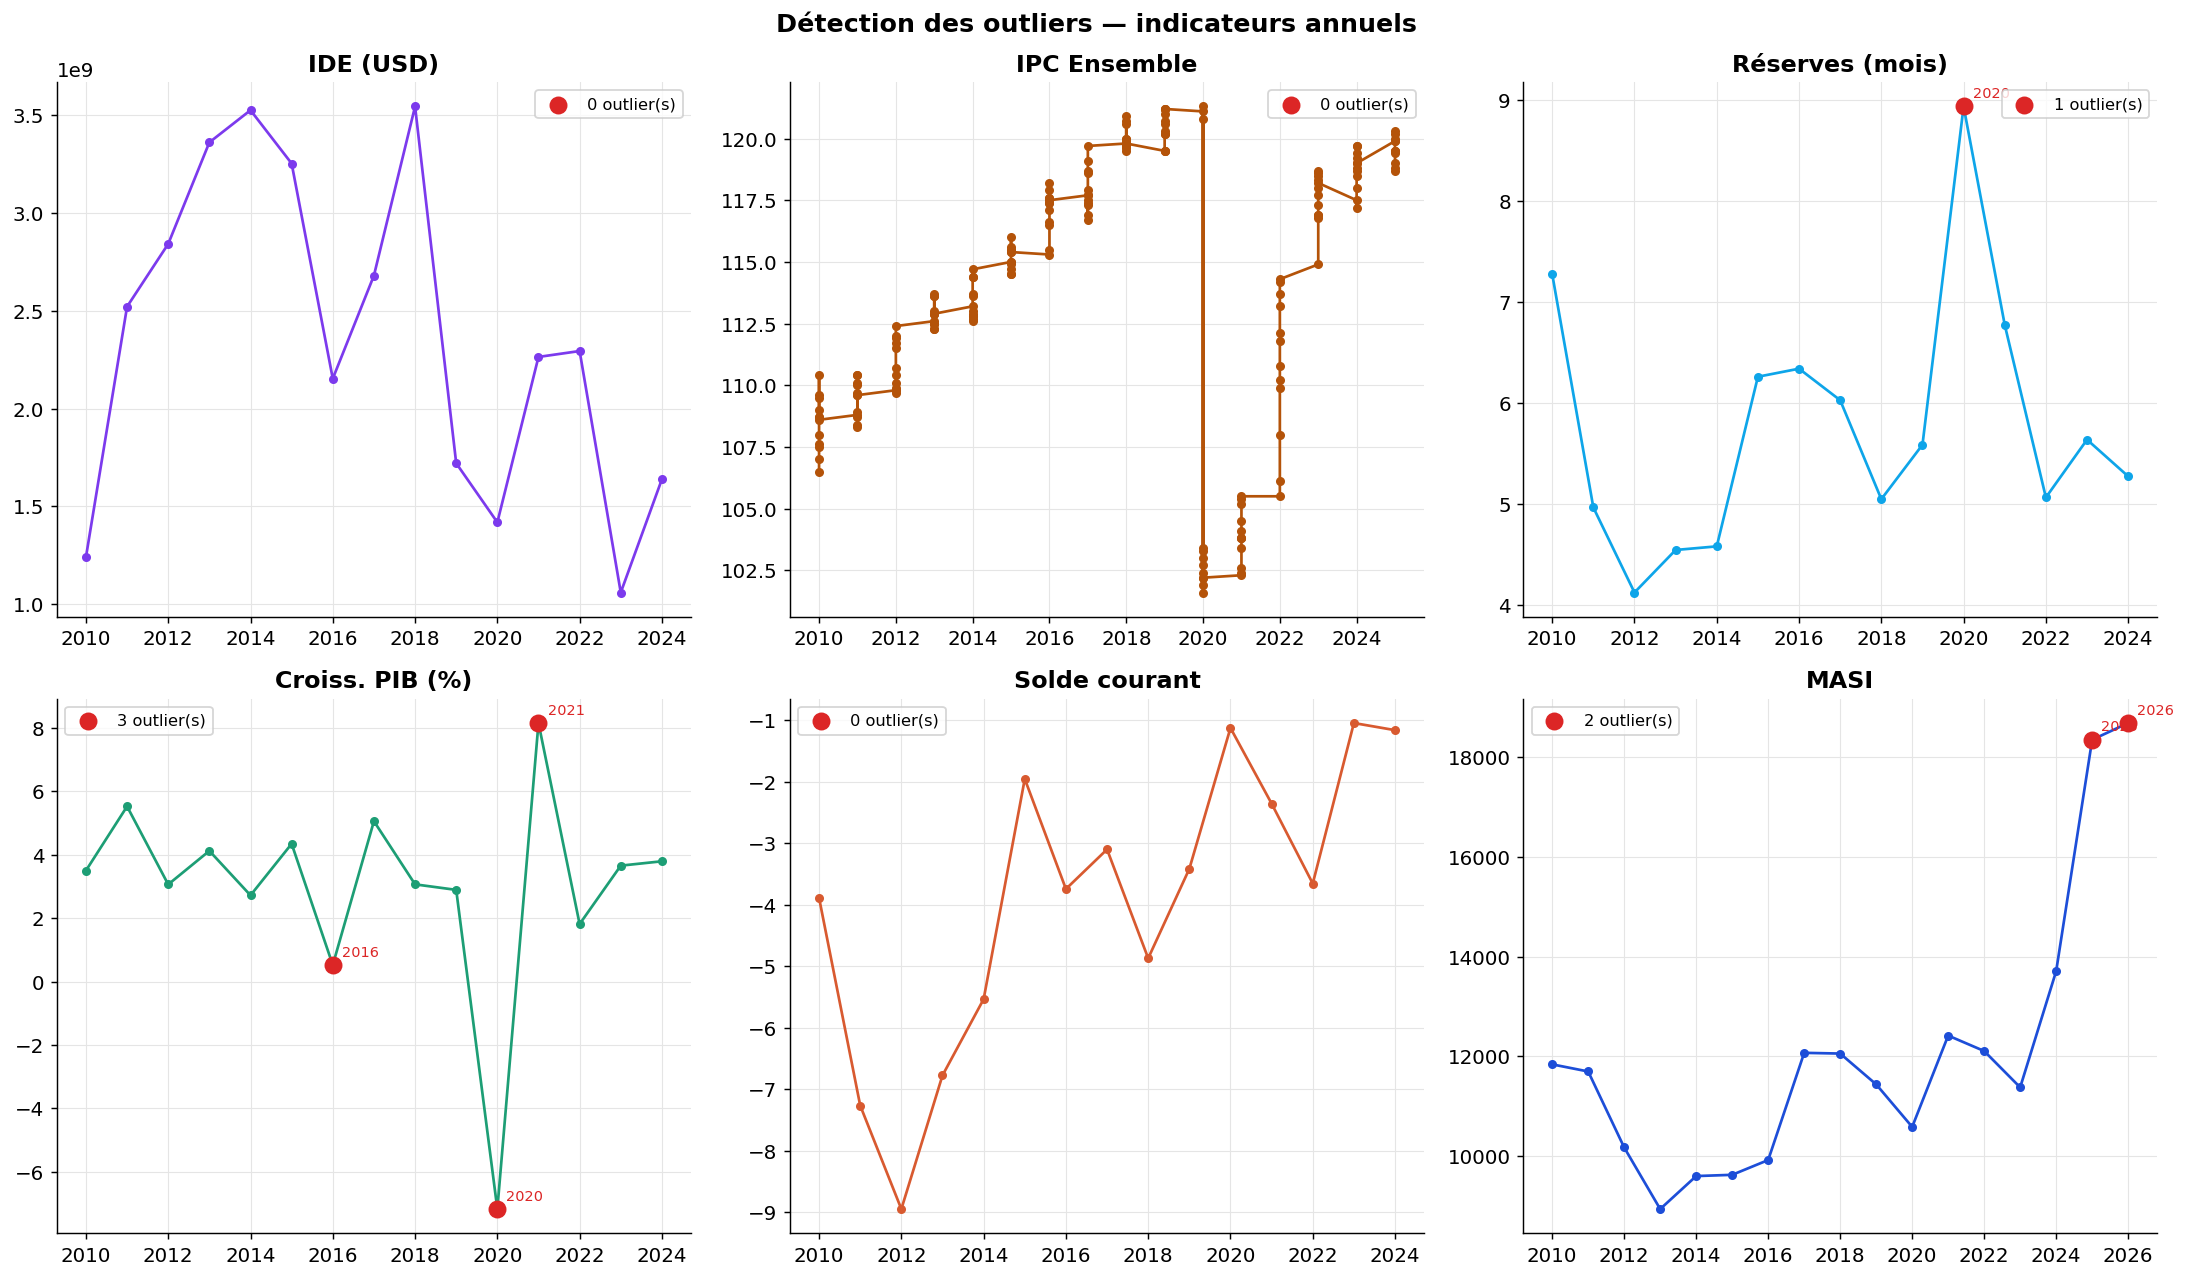

In [40]:
# Outliers sur les autres indicateurs

fig, axes = plt.subplots(2, 3, figsize=(17, 10))
fig.suptitle("Détection des outliers — indicateurs annuels",
             fontsize=14, fontweight='bold')

series_annuelles = [
    (dfs_dict['ide_global_cleaned'],  'Year',  'IDE_USD',        'IDE (USD)',        '#7C3AED'),
    (dfs_dict['ipc_cleaned'],         'annee', 'Ensemble',       'IPC Ensemble',     '#B45309'),
    (dfs_dict['reserves_cleaned'],    'year',  'value_months',   'Réserves (mois)',  '#0EA5E9'),
    (dfs_dict['macro_cleaned'],       'year',  'gdp_growth',     'Croiss. PIB (%)',  '#1D9E75'),
    (dfs_dict['macro_cleaned'],       'year',  'current_account','Solde courant',    '#D85A30'),
    (dfs_dict['masi_cleaned']
     .assign(Date=lambda x: pd.to_datetime(x['Date']))
     .assign(year=lambda x: x['Date'].dt.year)
     .groupby('year')['Cloture'].mean().reset_index(),
     'year', 'Cloture', 'MASI', '#1D4ED8'),
]

for ax, (df, xcol, ycol, label, color) in zip(axes.flat, series_annuelles):
    vals = df[ycol].dropna()
    Q1, Q3 = vals.quantile(0.25), vals.quantile(0.75)
    IQR = Q3 - Q1
    mask_out = (df[ycol] < Q1 - 1.5*IQR) | (df[ycol] > Q3 + 1.5*IQR)
    
    ax.plot(df[xcol], df[ycol], color=color,
            linewidth=1.5, marker='o', markersize=4)
    ax.scatter(df.loc[mask_out, xcol], df.loc[mask_out, ycol],
               color='#DC2626', s=80, zorder=5,
               label=f'{mask_out.sum()} outlier(s)')
    
    # Annoter les outliers
    for _, row in df[mask_out].iterrows():
        ax.annotate(str(int(row[xcol])),
                    (row[xcol], row[ycol]),
                    fontsize=8, color='#DC2626',
                    xytext=(5, 5), textcoords='offset points')
    
    ax.set_title(label, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, color='#E5E5E5', linewidth=0.6)

plt.tight_layout()
plt.savefig("../visualisation/viz_16_outliers_autres.png", bbox_inches='tight', dpi=150)
plt.show()